# 4 · Hands-on: $g^{(2)}$ from Click Data

**Interactive session · Tuesday July 28, 10:30–11:30 · work in pairs**

Three simulated Hanbury Brown–Twiss measurements, straight from the (virtual) time tagger: `source_A`, `source_B`, `source_C`. One is a **laser**, one a **thermal source**, one a **single quantum emitter** — and the file names won't tell you which.

**Your mission: identify all three from the raw time tags, with quantitative evidence.**

### Learning objectives

1. compute $g^{(2)}(\tau)$ from raw time tags via a coincidence histogram,
2. classify unknown light sources by their photon statistics,
3. quantify how uncorrelated **background** degrades an antibunching measurement,
4. fit correlation times and interpret them as source physics,
5. recognize source drift from the $g^{(2)}$ baseline — why $g^{(2)}(\infty) = 1$ is the stationarity certificate of a run.

### The data

Each `.npz` file contains an HBT recording (50:50 beamsplitter, one detector per arm, 10 s of data, ~25 000 detected photons/s total, plus realistic dark counts and timing jitter):

| array | meaning |
|---|---|
| `t1` | detector-1 arrival times, **integer nanoseconds**, sorted |
| `t2` | detector-2 arrival times, integer nanoseconds, sorted |
| `duration_ns` | total measurement time in ns |

*(The generator script is [`data/make_timetags.py`](../data/make_timetags.py) — reading it won't spoil the answer, the assignment is shuffled by the random seed.)*

### The hour, as one investigation

| step | exercise | the question |
|---|---|---|
| **measure** | E1 | turn raw tags into a $g^{(2)}(\tau)$ you trust |
| **identify** | E2 | which source is which — with evidence |
| **stress-test** | E3 | how much background before the certificate lies? |
| **interpret** | E4 | what do the timescales say about the source physics? |
| **distrust** | E5 | is the *instrument* lying? $g^{(2)}(\infty)$ as the stationarity check |
| **choose** | E6 | which normalization answers your question — the blinking emitter |

If the hour isn't over after the QuTiP cross-check, two more rounds (P3, P4) continue the same theme — *every claim needs an error bar, and know what survives loss*. Everything else (P1, P2, P5 and the $P(n)$-reconstruction stretch) is take-home at the bottom.

In [2]:
# Setup + data loading. Works in Codespaces (files are in the repo)
# and on Google Colab (downloads the files from GitHub on first run).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})

# Where the data lives relative to this notebook; falls back to GitHub raw.
GITHUB_REPO = "laserlab/CountingPhotons"   # <- adjust if the course repo moves
DATA_DIR = "../data" if os.path.isdir("../data") else "data"

def load_source(letter: str) -> dict:
    """Load one HBT time-tag recording, downloading it if necessary.

    Returns a dict with t1, t2 (int64 nanoseconds, sorted) and
    duration_ns (float).
    """
    fname = f"source_{letter}_timetags.npz"
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        url = (f"https://raw.githubusercontent.com/{GITHUB_REPO}"
               f"/main/data/{fname}")
        print("downloading", url)
        urllib.request.urlretrieve(url, path)
    d = np.load(path)
    return {"t1": d["t1"].astype(np.int64),   # int64: we will subtract times!
            "t2": d["t2"].astype(np.int64),
            "duration_ns": float(d["duration_ns"])}

sources = {letter: load_source(letter) for letter in "ABC"}
for letter, d in sources.items():
    rate_kcps = (d["t1"].size + d["t2"].size) / d["duration_ns"] * 1e6
    print(f"source_{letter}: {d['t1'].size:6d} + {d['t2'].size:6d} tags, "
          f"{rate_kcps:5.1f} kcps total")

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

source_A: 127119 + 127211 tags,  25.4 kcps total
source_B: 126750 + 127132 tags,  25.4 kcps total
source_C: 127110 + 126549 tags,  25.4 kcps total


Same count rate everywhere — a power meter is useless here, as promised.

## Worked example: the coincidence histogram

$g^{(2)}(\tau)$ from time tags, in words:

1. for every click on detector 1, find all detector-2 clicks within $\pm\tau_{\max}$ (fast because the arrays are sorted → `np.searchsorted`),
2. histogram the time differences $\Delta t = t_2 - t_1$ in bins of width $\Delta\tau$,
3. **normalize** by what uncorrelated streams would give: $N_{\rm acc} = r_1 r_2 T \Delta\tau$ coincidences per bin, where $r_i$ are the count rates and $T$ the total time. Dividing by $N_{\rm acc}$ makes flat = 1, so the histogram becomes $g^{(2)}(\tau)$.

**How the normalization inside the function works.** Throw $N_1$ and $N_2$ darts at random onto a $T$-long timeline: $N_1 N_2\,\Delta\tau/T$ pairs land within the same $\Delta\tau$ of each other — here ≈161 per 100-ns bin. That is the denominator (`accidentals` $= r_1 r_2\, T\,\Delta\tau$): the coincidences *pure chance* would produce. Dividing by it makes the scale self-calibrating — wings → 1 (chance), thermal peak → 2 (twice chance), perfect antibunching → 0. Everything above or below chance is physics. (And the denominator hides one assumption — *stationarity* — whose breakdown is the subject of Exercises 5 and 6.)

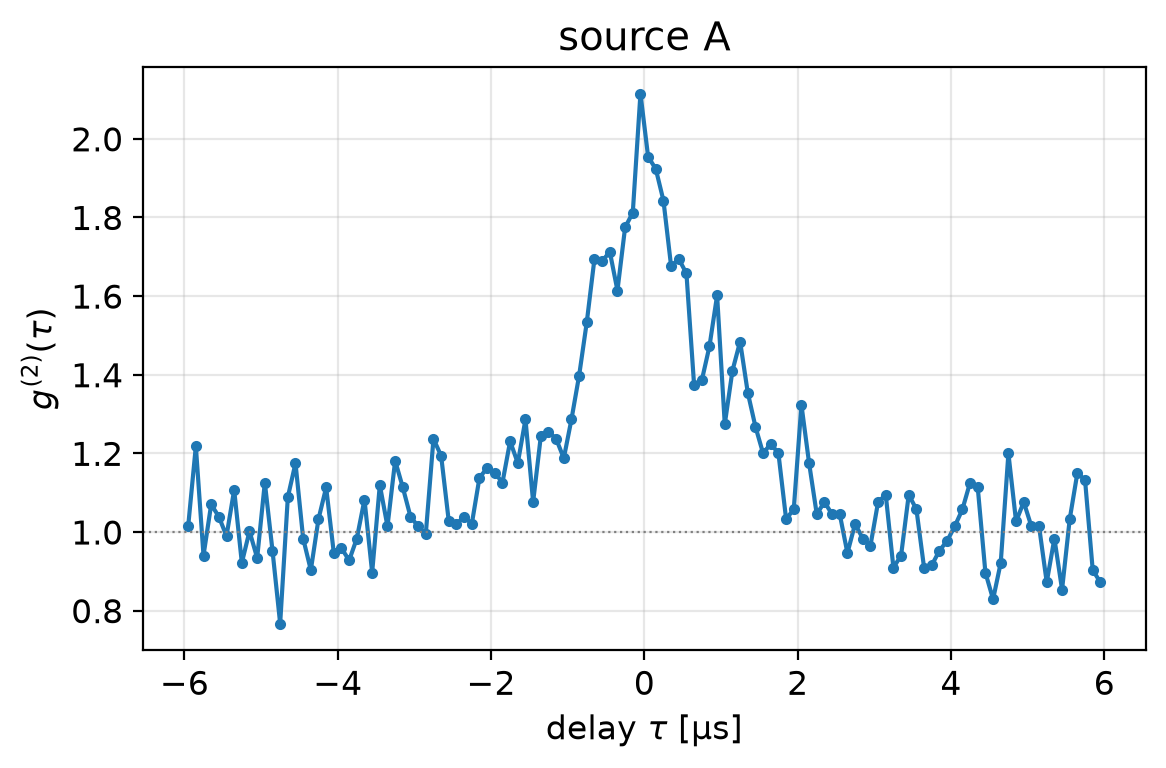

In [3]:
def g2_from_timetags(t1: np.ndarray, t2: np.ndarray, duration_ns: float,
                     window_ns: int = 6000, bin_ns: int = 100):
    """Normalized coincidence histogram g2(tau) from two HBT tag streams.

    Parameters
    ----------
    t1, t2 : sorted int64 arrays, arrival times [ns]
    duration_ns : total measurement time [ns]
    window_ns : histogram spans -window .. +window [ns]
    bin_ns : histogram bin width [ns]

    Returns
    -------
    tau_ns : bin centers [ns]
    g2 : normalized coincidence counts (dimensionless, ->1 for tau -> inf)
    """
    edges = np.arange(-window_ns, window_ns + bin_ns, bin_ns)
    counts = np.zeros(len(edges) - 1)
    # indices of the first/last t2 partner within the window, per t1 click
    lo = np.searchsorted(t2, t1 - window_ns)
    hi = np.searchsorted(t2, t1 + window_ns)
    for i, (a, b) in enumerate(zip(lo, hi)):
        if b > a:
            counts += np.histogram(t2[a:b] - t1[i], bins=edges)[0]
    # accidental (uncorrelated) coincidences per bin: r1 * r2 * T * bin
    accidentals = (t1.size / duration_ns) * (t2.size / duration_ns) \
        * duration_ns * bin_ns
    tau_ns = edges[:-1] + bin_ns / 2
    return tau_ns, counts / accidentals

# Try it on source A:
d = sources["A"]
tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
plt.plot(tau / 1000, g2, ".-")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.title("source A")
plt.tight_layout()
plt.show()

## Exercise 1 · All three sources

⏱ *In the session: try it yourself first (~3 min), compare with your neighbor — then we build the solution together.*

The analysis machinery is written for you — your job is to **steer it**. The scaffold below plots $g^{(2)}(\tau)$ for all three sources and prints $g^{(2)}(0)$ estimates. It has two marked knobs, and both are physics decisions, not coding:

* `bin_ns` — the histogram bin width. Too coarse and you average the features away (Brannen & Ferguson's mistake [BrannenFerguson1956], in bin form); too fine and every bin drowns in Poisson noise.
* `central_ns` — which bins count as "central" when averaging for $g^{(2)}(0)$.

Tune both until you trust your numbers, then read the **correlation time** of each feature off the figure (at which $|\tau|$ is it gone?). You will need all of this in Exercise 2.

source A: g2(0) ≈ 1.99 ± 0.18
source B: g2(0) ≈ 0.81 ± 0.11
source C: g2(0) ≈ 0.02 ± 0.02


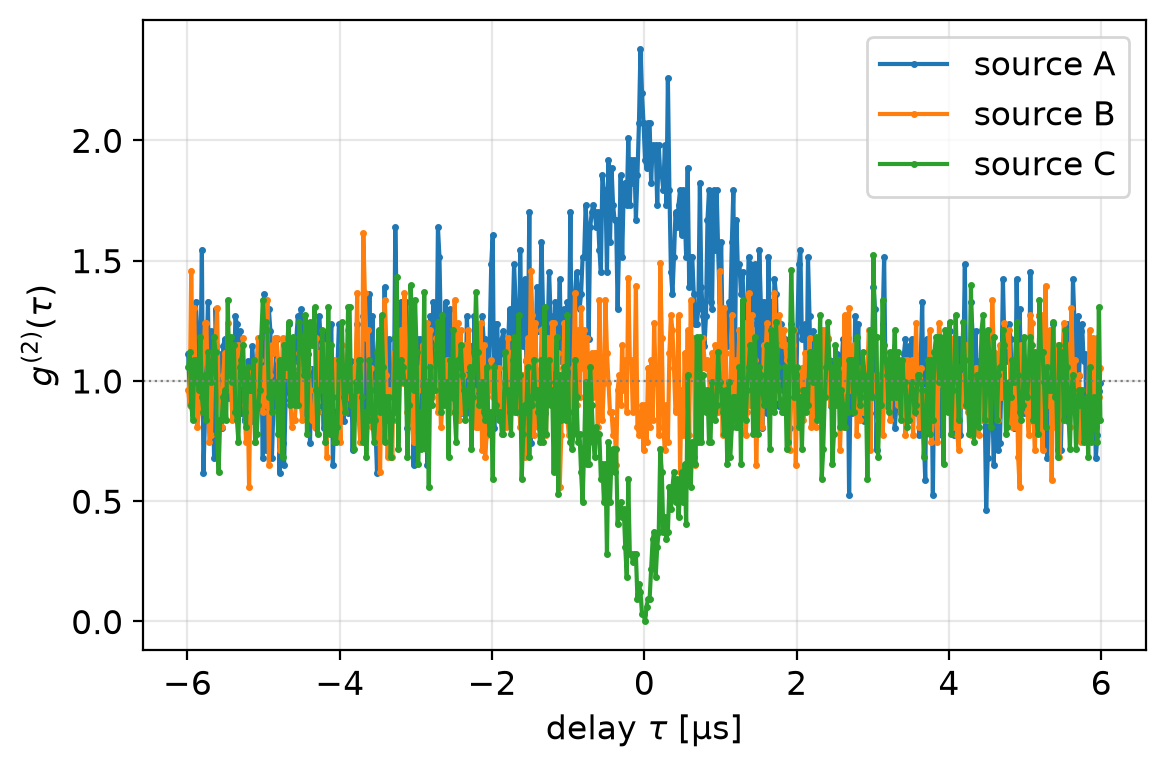

In [5]:
# YOUR CODE HERE - Exercise 1
# The analysis function (g2_from_timetags, defined above) is ready - you
# only steer it. Tune the two marked values and re-run until you trust
# the numbers. No other code needed.

bin_ns = 20       # <-- try 10 / 100 / 500 / 2000. What changes, and why?
central_ns = 20   # <-- |tau| below this counts as "central" for g2(0)

fig, ax = plt.subplots()
for letter in "ABC":
    d = sources[letter]
    tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"],
                               bin_ns=bin_ns)
    ax.plot(tau / 1000, g2, ".-", ms=3, label=f"source {letter}")
    # error bar - given plumbing: each bin carries sqrt(g2/A_acc) of
    # counting noise (Exercise 4 derives this); the mean over the n
    # central bins is sqrt(n) better. Carry the ± into Exercise 2!
    g2c = g2[np.abs(tau) < central_ns]
    A_acc = (d["t1"].size / d["duration_ns"]) \
        * (d["t2"].size / d["duration_ns"]) * d["duration_ns"] * bin_ns
    err = np.sqrt(g2c.mean() / (A_acc * g2c.size))
    print(f"source {letter}: g2(0) ≈ {g2c.mean():.2f} ± {err:.2f}")
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.set_xlabel(r"delay $\tau$ [µs]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.legend()
plt.tight_layout()
plt.show()

# Correlation times: read them off the figure and note them for Exercise 2.

> ⚠️ **Pitfall ledger — E1.** Binning is inference, not display: too coarse averages the physics away (Brannen & Ferguson's actual mistake), too fine drowns each bin in Poisson noise, and below the detector jitter you histogram the instrument. And the quoted $g^{(2)}(0)$ depends on what "central" means — state both choices next to the number.

## Exercise 2 · The verdict

⏱ *In the session: fill in your own verdict row first — then we poll the room and compare.*

Fill in (markdown cell — double-click):

| source | $g^{(2)}(0)$ | correlation time | identity | key evidence |
|---|---|---|---|---|
| A | 1.99 | | Thermal  | |
| B | 0.81 | | Coherent | |
| C | 0.02 | | Quantum  | |

*Cross-check with theory:* the single-mode predictions are $2$, $1$, and $\approx 0$. If your emitter's $g^{(2)}(0)$ is *not* $\approx 0$ — is that physics or is that your histogram? Re-run with `bin_ns=20` on the antibunched source before you blame the source. (Remember from the lecture: dark counts also push $g^{(2)}(0)$ up. Both effects are in this data.)

*(double-click to edit — your table here)*

> ⚠️ **Pitfall ledger — E2.** A classification without an error bar is an opinion: each bin here carries ~8% counting noise — exactly the wobble on source B's flat line. Quote the label with the numbers that carried it ($g^{(2)}(0)\pm\sigma$, correlation time), never alone. Where does σ come from before Exercise 4 derives it? Two ways that work right now: read it off Exercise 1's printout (the given ± line) — or use the built-in noise ruler: the wobble of a flat stretch of wings *is* the per-bin σ, and source B is one long flat stretch.

## Exercise 3 · How much background can antibunching survive?

⏱ *In the session: try it yourself first (~3 min), compare with your neighbor — then we build the solution together.*

Real measurements sit on uncorrelated background (dark counts, stray light). You will now *add* extra background to the antibunched source and watch the certificate $g^{(2)}(0) < 0.5$ fail.

All the plumbing is provided — background injection, the sweep (0 to 20 kcps added per detector; the source itself runs ≈12.5 kcps, so the sweep reaches $p \approx 0.6$), and the plot. Your inputs are physics decisions:

1. Tell the scaffold **which source is the antibunched one** (your Exercise-2 verdict). If you pick wrong, the plot will tell you — how?
2. **Predict before you run**: at which background fraction $p$ does $g^{(2)}(0)$ cross 0.5? Put your guess in `p_fail_guess`. Reasoning tool: background *dilutes* the dip toward 1, because the three kinds of coincidence mix — both clicks signal ($(1-p)^2$, carrying the true dip), one signal + one background ($2p(1-p)$, uncorrelated → flat at 1), both background ($p^2$, also flat).
3. **The theory curve is one line — and the line is the physics**: translate $g^{(2)}_{\rm meas}(0) = g^{(2)}_{\rm true}(0)\,(1-p)^2 + 2p(1-p) + p^2$ into the marked `g2_theory =` assignment. For $g^{(2)}_{\rm true}(0)$ use the **measured** value at zero added background (`g2_measured[0]`) — it already contains the intrinsic dark counts. *(Take-home: show the formula collapses to $1 - (1-g^{(2)}_{\rm true})(1-p)^2$ and solve for the crossing $p^*$.)*

Then read off where the certificate actually fails — do data, theory, and your guess agree?

And one reading question about the given function: why must the merged tag stream stay **sorted**?

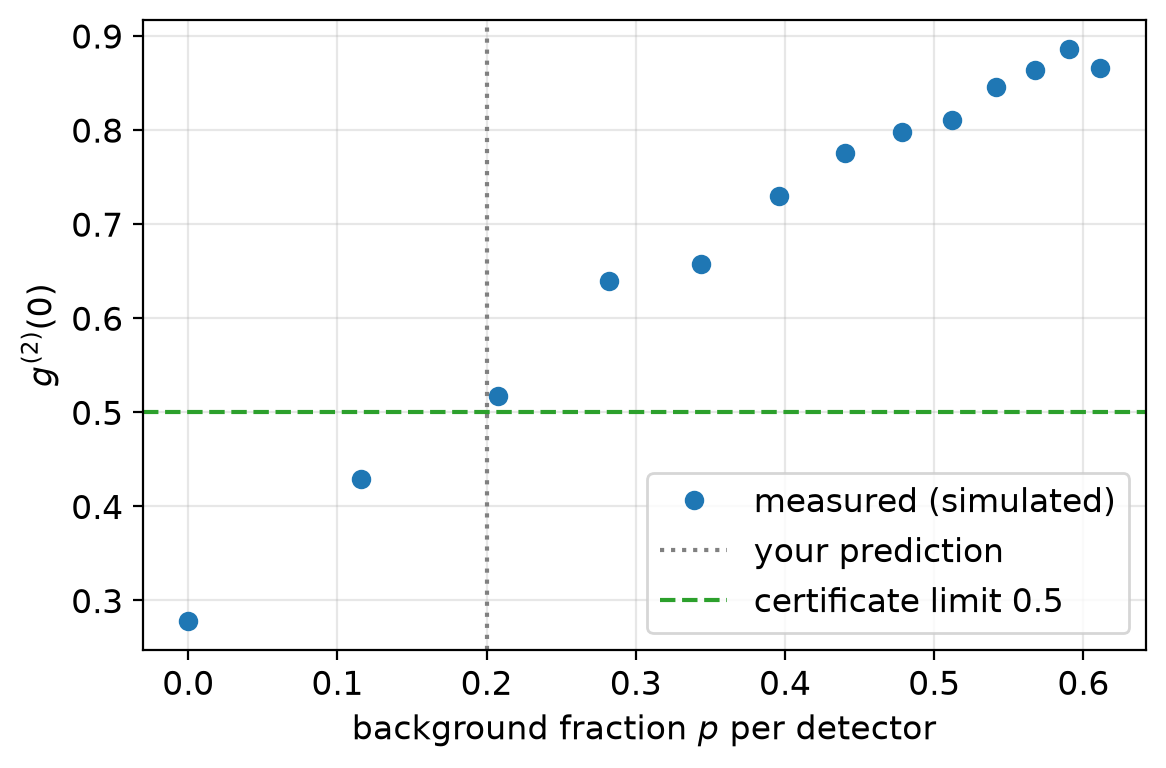

In [7]:
# YOUR CODE HERE - Exercise 3
# Given - plumbing, not physics: background injection, sweep, plot.
rng = np.random.default_rng(1)

def add_background(t, duration_ns, rate_cps, rng):
    """Merge uncorrelated Poissonian background clicks into a tag stream."""
    n_bg = rng.poisson(rate_cps * duration_ns * 1e-9)
    t_bg = rng.integers(0, int(duration_ns), n_bg)
    return np.sort(np.concatenate([t, t_bg]))

bg_rates = np.linspace(0, 20e3, 13)   # [cps per detector]; source: ~12.5 kcps

# Your physics inputs:
antibunched = "C"        # <-- 1. your Exercise-2 verdict
p_fail_guess = 0.2     # <-- 2. PREDICT: p where g2(0) crosses 0.5

d = sources[antibunched]
signal_rate = d["t1"].size / (d["duration_ns"] * 1e-9)   # cps per detector

fractions, g2_measured = [], []
for r_bg in bg_rates:
    t1b = add_background(d["t1"], d["duration_ns"], r_bg, rng)
    t2b = add_background(d["t2"], d["duration_ns"], r_bg, rng)
    tau, g2 = g2_from_timetags(t1b, t2b, d["duration_ns"])
    fractions.append(r_bg / (r_bg + signal_rate))
    g2_measured.append(g2[np.abs(tau) < 300].mean())
fractions = np.array(fractions)

# 3. The theory line IS the physics - translate the formula from the text
#    (g2_true = the p = 0 point of this very sweep):
g2_true = g2_measured[0]
g2_theory = None         # <-- e.g.  g2_true * (1 - fractions)**2 + ...

plt.plot(fractions, g2_measured, "o", label="measured (simulated)")
if g2_theory is not None:
    plt.plot(fractions, g2_theory, "-", label="background model")
if p_fail_guess is not None:
    plt.axvline(p_fail_guess, color="gray", ls=":", label="your prediction")
plt.axhline(0.5, color="tab:green", ls="--", label="certificate limit 0.5")
plt.xlabel("background fraction $p$ per detector")
plt.ylabel(r"$g^{(2)}(0)$")
plt.legend(); plt.tight_layout(); plt.show()

> ⚠️ **Pitfall ledger — E3.** Background enters through *both* detectors — the certificate dies by $(1-p)^2$, here at $p^* \approx 0.17$ (2.6 kcps: an open lab door). Failing the witness does not make the source classical — witnesses are sufficient, never necessary. Correcting with the model is legitimate only if $p$ was measured independently; quote raw *and* corrected.

## Exercise 4 · The dip is spectroscopy: fit the correlation times

⏱ *In the session: try it yourself first (~3 min), compare with your neighbor — then we build the solution together.*

From the lecture: the *shape* of $g^{(2)}(\tau)$ measures the source's internal timescale — coherence time for thermal light, recovery time (set jointly by lifetime and re-excitation) for a single emitter. The two model functions and the `curve_fit` call are wired in the scaffold; your inputs:

1. **Assign models to sources** (which source gets $1 + a\,e^{-2|\tau|/\tau_c}$, which $1 - b\,e^{-|\tau|/\tau_r}$?) and supply a sensible initial guess `p0`.
2. **Put honest error bars on every bin.** Why $\sqrt{N_c}$: a bin counts *coincidence events* — many, individually rare, nearly independent pair-events — which is the textbook condition for Poisson counting statistics, *whatever the light's photon statistics are*. (The source sets the **mean** $N_c$ of each bin — dip, peak — not the counting noise of the histogram; at our rates a click has only ~10⁻³ chance to contribute twice to one bin.) Shot noise of the coincidence counter, not of the beam. The accidental level `A_acc` (the normalization denominator, ≈161 per bin) is given — your input is the propagation through $g^{(2)} = N_c/A_{\rm acc}$, one marked line. Before fitting, look: **where on the curve are the absolute error bars smallest?** Then compare the fitted uncertainty with `sigma=None`: without weights, `curve_fit` *invents* error bars from the scatter; with them, your ± is traceable to counting statistics.
3. Report $\tau_c$ and $\tau_r$ with uncertainties. Ground truth (see [`data/make_timetags.py`](../data/make_timetags.py)): coherence time 2 µs; emitter with 1 µs excitation + 1 µs emission time. Do your fits agree — and *should* $\tau_r$ equal 2 µs? (Think: what combination of the two rates sets the antibunching recovery?)

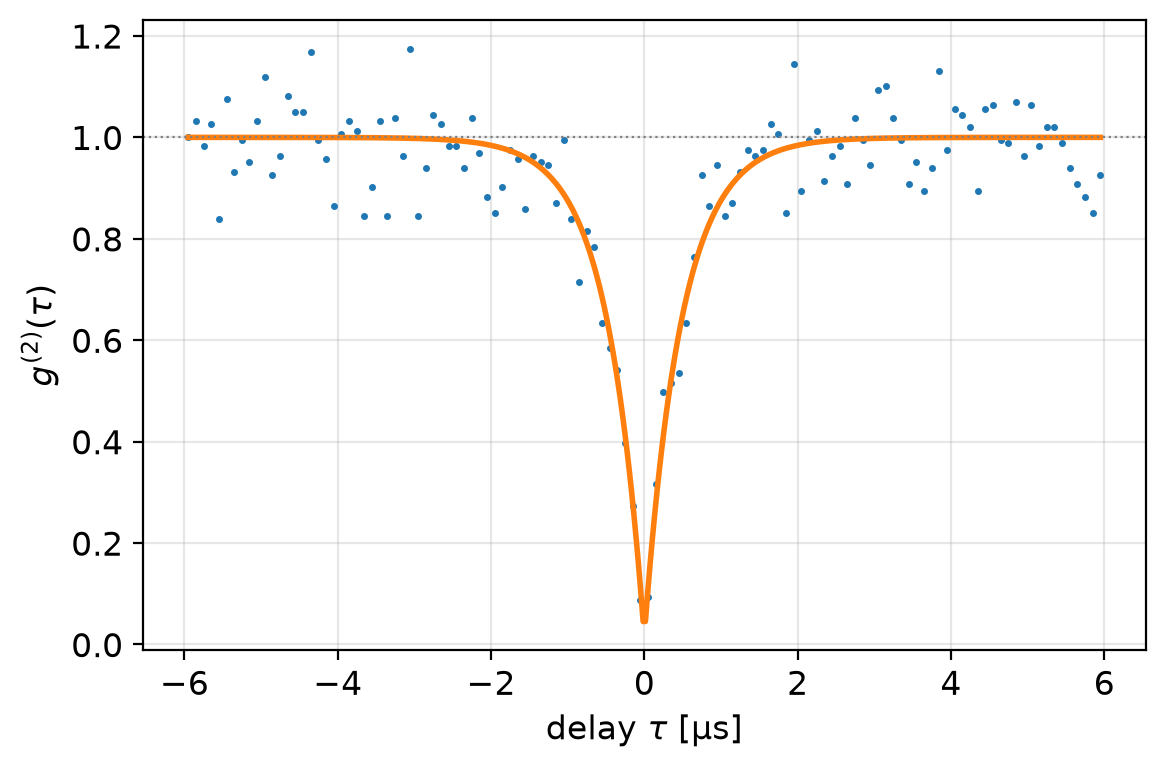

fitted time: 0.48 ± 0.03 µs


In [8]:
# YOUR CODE HERE - Exercise 4
from scipy.optimize import curve_fit

def model_thermal(tau, a, tau_c):
    """Bunching of chaotic light: g2 = 1 + a*exp(-2|tau|/tau_c)."""
    return 1 + a * np.exp(-2 * np.abs(tau) / tau_c)

def model_emitter(tau, b, tau_r):
    """Antibunching recovery: g2 = 1 - b*exp(-|tau|/tau_r)."""
    return 1 - b * np.exp(-np.abs(tau) / tau_r)

# Your inputs (run once per source):
letter = "C"                              # <-- which source...
model, p0 = model_emitter, (1.0, 2000.0)  # <-- ...gets which model + guess (ns)?

d = sources[letter]
tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])

# Given - the accidental level (the normalization denominator):
A_acc = (d["t1"].size / d["duration_ns"]) \
    * (d["t2"].size / d["duration_ns"]) * d["duration_ns"] * 100  # per bin

# Step 2 - your input: error bars on each bin, in three small steps.
#   undo the normalization:  N_c   = g2 * A_acc     (raw counts per bin)
#   Poisson-count noise:     dN_c  = sqrt(N_c)
#   normalize back:          sigma = dN_c / A_acc
# Combine into one line. Sanity check before fitting: a wing bin
# (g2 = 1, A_acc = 161) should give sigma = 1/sqrt(161) = 0.079.
sigma = None                              # <-- your one line here

popt, pcov = curve_fit(model, tau, g2, p0=p0, sigma=sigma,
                       absolute_sigma=sigma is not None)
perr = np.sqrt(np.diag(pcov))

plt.plot(tau / 1000, g2, ".", ms=3)
tt = np.linspace(tau.min(), tau.max(), 400)
plt.plot(tt / 1000, model(tt, *popt), lw=2)
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]"); plt.ylabel(r"$g^{(2)}(\tau)$")
plt.tight_layout(); plt.show()
print(f"fitted time: {popt[1]/1000:.2f} ± {perr[1]/1000:.2f} µs")

> ⚠️ **Pitfall ledger — E4.** Least squares never complains about missing error bars — it silently invents them from the scatter. Poisson weights are $\sqrt{N_c}/A$; a zero-count bin must not claim $\sigma = 0$ (silence is not certainty — hence the `max(N, 1)` in the solution). And a fitted time constant is a *combination of rates*, not automatically "the lifetime".

## Exercise 5 · The lie detector: $g^{(2)}(\infty)$ and the drifting source

⏱ *In the session: try it yourself first (~3 min), compare with your neighbor — then we build the solution together.*

Every estimate so far normalized the histogram by the accidental level $r_1 r_2\,\Delta\tau\,T$ — *average* rates over the whole run. That silently assumes the source is **stationary**. Real sources are not: pump power wanders, fiber coupling breathes, emitters blink. What does slow drift do to $g^{(2)}$?

The scaffold takes the **coherent** source and modulates its detected intensity slowly and *in common* on both detectors — $I(t) \propto 1 + m\sin(2\pi t/T_{\rm mod})$ with $T_{\rm mod} = 100$ µs, far slower than the ±6 µs correlation window. Your physics inputs:

1. **Predict before you run** (`plateau_guess`): does the measured $g^{(2)}$ window move up, down, or stay at 1?
2. Run, read the plateau, then enter the theory (`plateau_theory`) — one line of algebra from Monday's wave term: for drift much slower than the window, $g^{(2)} = \langle I^2\rangle/\langle I\rangle^2 = 1 + m^2/2$.
3. **Interpretation** (discuss with your neighbor): the curve looks like weak bunching. How would you distinguish this instrument artifact from genuine thermal bunching — what $\tau$ would you need to reach, or what else would you monitor? And the sharp question about normalization: if we had normalized by the *wings* of the histogram instead of by $r_1 r_2\,T$, what would the plot have shown?

This is the classical bound doing real work: any classical intensity noise pushes $g^{(2)}$ **above** 1 — drift can fake bunching, but nothing classical can fake a dip. A flat baseline at exactly 1 is therefore a *stationarity certificate* for the whole run — this morning's field-guide rule ("check the wings settle at 1") is this exercise in one sentence.

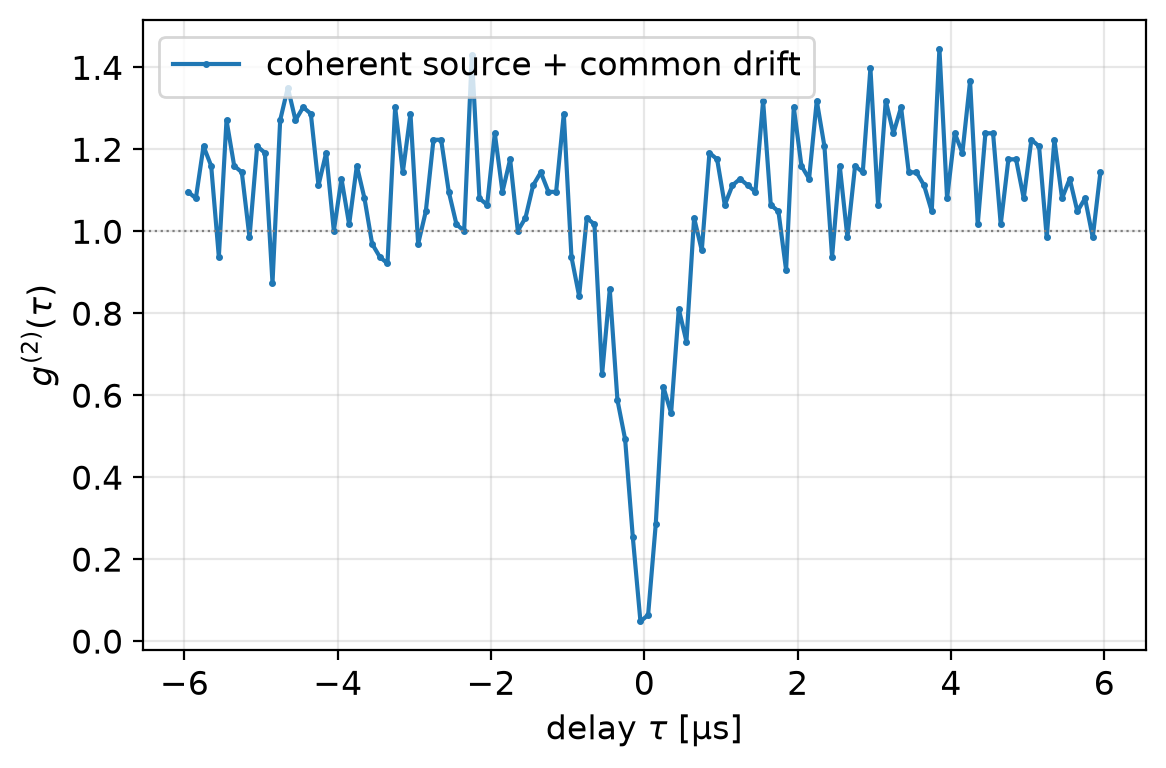

window-averaged g2 = 1.067


In [9]:
# YOUR CODE HERE - Exercise 5
# Given: common slow intensity modulation on both detectors (pump drift).
def modulate(t, m, period_ns, rng):
    """Keep each tag with probability ∝ 1 + m*sin(2π t/period): slow drift."""
    prob = (1 + m * np.sin(2 * np.pi * t / period_ns)) / (1 + m)
    return t[rng.uniform(size=t.size) < prob]

coherent = "C"           # <-- your Exercise-2 verdict for the coherent source
m, period_ns = 0.6, 100_000       # 60% drift depth, 100 µs period

# Your physics inputs:
plateau_guess = None     # <-- 1. PREDICT the g2 baseline before running
plateau_theory = None    # <-- 2. after running: enter 1 + m**2/2

rng5 = np.random.default_rng(5)
d = sources[coherent]
t1m = modulate(d["t1"], m, period_ns, rng5)
t2m = modulate(d["t2"], m, period_ns, rng5)
tau, g2 = g2_from_timetags(t1m, t2m, d["duration_ns"])

plt.plot(tau / 1000, g2, ".-", ms=3, label="coherent source + common drift")
plt.axhline(1, color="gray", ls=":", lw=0.8)
if plateau_theory is not None:
    plt.axhline(plateau_theory, color="tab:red", ls="--",
                label=rf"theory $1+m^2/2$ = {plateau_theory:.2f}")
plt.xlabel(r"delay $\tau$ [µs]")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.legend(); plt.tight_layout(); plt.show()
print(f"window-averaged g2 = {g2.mean():.3f}")

> ⚠️ **Pitfall ledger — E5.** The accidental level $r_1 r_2 T$ assumes stationarity — check that the wings settle at 1 before reading anything else. A floated baseline with intact fast features means the *run* drifted, not that the source physics changed.

## Exercise 6 · The blinking emitter — which normalization answers your question?

⏱ *In the session: try it yourself first (~3 min), compare with your neighbor — then we build the solution together.*

Real single emitters **blink**: NV centers shelve into a metastable state, colloidal dots charge and go dark (this morning's field-guide rows). Blinking is Exercise 5's slow common modulation — but now on a *genuinely quantum* source: the same curve carries an antibunching dip **and** classical excess at once. The telegraph gate (100 µs ON / 150 µs OFF, duty cycle $\beta = 0.4$, dwell ≫ window) is given; your inputs:

1. Which source is the emitter (Exercise-2 verdict) — and **predict** the rate-normalized wing level (`wings_guess`).
2. Slow *multiplicative* modulation factorizes: $g^{(2)}_{\rm meas}(\tau) = g^{(2)}_{\rm blink}(\tau)\cdot g^{(2)}_{\rm emitter}(\tau)$, and for $\tau \ll$ dwell, $g^{(2)}_{\rm blink} = \langle s^2\rangle/\langle s\rangle^2$. The one-line derivation, right here in the margin: a telegraph only takes the values 0 and 1, so $s^2 = s$ — **the signal is its own square** — hence $\langle s^2\rangle = \langle s\rangle = \beta$ and $g^{(2)}_{\rm blink} = \beta/\beta^2 = 1/\beta$. Enter it as `wings_theory`. (Compare Exercise 5: the sine drift gave $\langle I^2\rangle/\langle I\rangle^2 = 1 + m^2/2$ — same quantity, different modulation. A telegraph is *maximally* noisy: for $\beta \to 0$ the excess diverges — a rarely-ON emitter looks dramatically "thermal" under rate normalization — while for $\beta \to 1$ it disappears.)
3. Read both printed dips. **Which certificate survives which normalization — and which physical question does each answer?** Rate-normalized: "is this a *steady stream* of single photons?" (no — it blinks). Wing-normalized: "is each emission event antibunched?" (yes — the emitter physics is intact).

And why does the wing-normalized curve recover the emitter *exactly*, for every $\beta$? Because the blinking is multiplicative and slow: in the ratio $g^{(2)}_{\rm meas}(\tau)/\text{wings}$ the factor $1/\beta$ cancels identically — only physics faster than the dwell time survives the division.

The punchline, paired with Exercise 5: there the wing trick would have *hidden* a drift artifact; here it is the *correct tool* to isolate the intrinsic statistics. Same manipulation, opposite verdict — because the question changed. **Normalization is not bookkeeping; it is choosing the question.** Papers on blinking emitters quote wing-normalized $g^{(2)}(0)$ — and must say so.

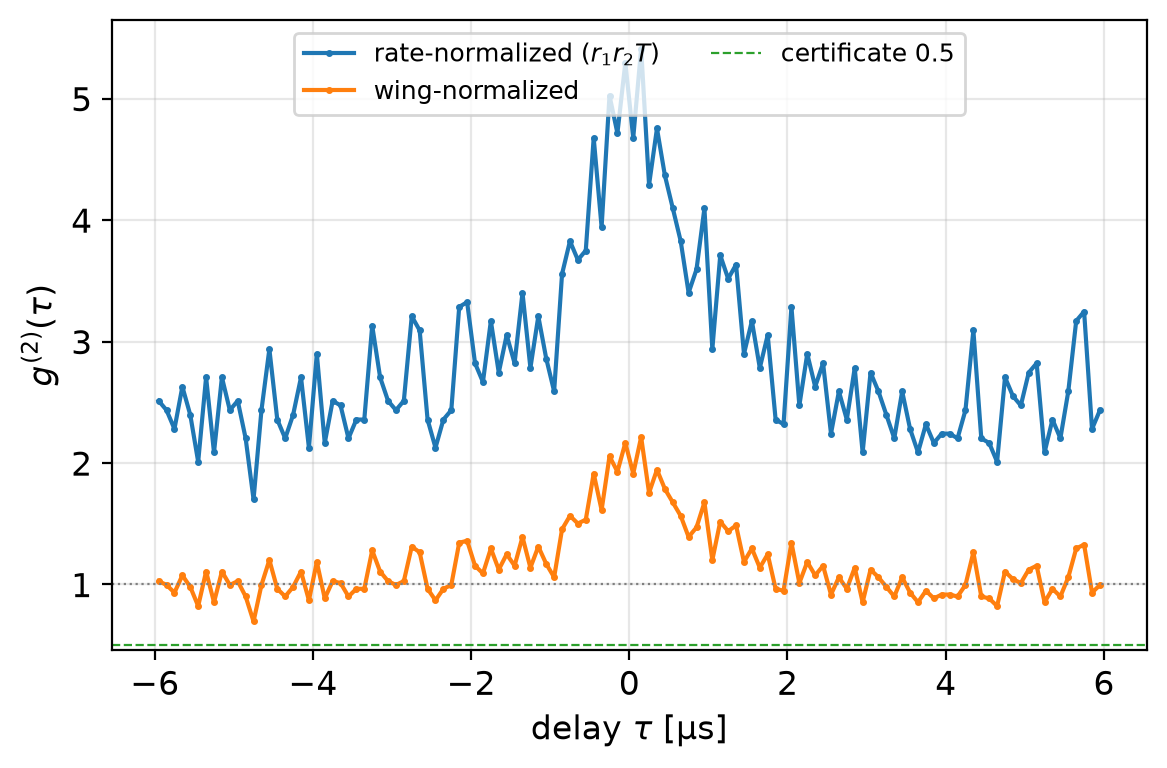

rate-normalized: wings = 2.44, dip = 4.90 -> certificate FAILS
wing-normalized: wings = 1.00, dip = 2.01 -> certificate FAILS


In [7]:
# YOUR CODE HERE - Exercise 6
# Given - a random-telegraph blink gate, applied IN COMMON to both detectors:
def telegraph_edges(dwell_on_ns, dwell_off_ns, duration_ns, rng):
    """Switching times of an ON/OFF telegraph (starts ON)."""
    edges, t, on = [0.0], 0.0, True
    while t < duration_ns:
        t += rng.exponential(dwell_on_ns if on else dwell_off_ns)
        edges.append(t)
        on = not on
    return np.array(edges)

def apply_gate(t, edges):
    """Keep only tags that fall into ON intervals of the telegraph."""
    return t[(np.searchsorted(edges, t, side="right") - 1) % 2 == 0]

dwell_on_ns, dwell_off_ns = 100_000, 150_000    # 100 µs ON / 150 µs OFF
beta = dwell_on_ns / (dwell_on_ns + dwell_off_ns)   # duty cycle = 0.4
rng6 = np.random.default_rng(6)

# Your physics inputs:
emitter = "A"          # <-- your antibunched source (Exercise-2 verdict)
wings_guess = None     # <-- 1. PREDICT the rate-normalized wing level
wings_theory = None    # <-- 2. after running: the law, in beta

d = sources[emitter]
edges = telegraph_edges(dwell_on_ns, dwell_off_ns, d["duration_ns"], rng6)
t1b = apply_gate(d["t1"], edges)
t2b = apply_gate(d["t2"], edges)
tau, g2 = g2_from_timetags(t1b, t2b, d["duration_ns"])

wings = g2[np.abs(tau) > 4000].mean()      # measured wing level
g2_wing = g2 / wings                       # the wing-normalized curve

fig, ax = plt.subplots()
ax.plot(tau / 1000, g2, ".-", ms=3, label="rate-normalized ($r_1 r_2 T$)")
ax.plot(tau / 1000, g2_wing, ".-", ms=3, label="wing-normalized")
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.axhline(0.5, color="tab:green", ls="--", lw=0.8, label="certificate 0.5")
if wings_theory is not None:
    ax.axhline(wings_theory, color="tab:red", ls="--", lw=0.8,
               label="your law for the wings")
ax.set_xlabel(r"delay $\tau$ [µs]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.legend(fontsize=9, ncol=2, loc="upper center")
plt.tight_layout(); plt.show()

dip = g2[np.abs(tau) < 300].mean()
dip_w = g2_wing[np.abs(tau) < 300].mean()
print(f"rate-normalized: wings = {wings:.2f}, dip = {dip:.2f} -> "
      f"certificate {'passes' if dip < 0.5 else 'FAILS'}")
print(f"wing-normalized: wings = 1.00, dip = {dip_w:.2f} -> "
      f"certificate {'passes' if dip_w < 0.5 else 'FAILS'}")


> ⚠️ **Pitfall ledger — E6.** "$g^{(2)}(0) = \ldots$" means nothing until you say *normalized to what*. Rate normalization asks "steady single-photon stream?"; wing normalization asks "each emission antibunched?". Both are standard; reproducibility dies when the choice is implicit. Report the normalization — and the duty cycle.

## Cross-check with QuTiP (worked)

The time-tag estimate should agree with the operator expectation value $g^{(2)}(0) = \langle \hat n(\hat n-1)\rangle/\langle\hat n\rangle^2$ for the matching states:

In [8]:
def g2_zero_state(state) -> float:
    """g2(0) of a single-mode QuTiP state (ket or density matrix)."""
    n_op = qutip.num(state.shape[0])
    mean_n = qutip.expect(n_op, state)
    return qutip.expect(n_op * (n_op - 1), state) / mean_n**2

N = 40
print("QuTiP single-mode predictions:")
print(f"  thermal (any nbar): g2(0) = {g2_zero_state(qutip.thermal_dm(N, 2.0)):.3f}")
print(f"  coherent (any α):   g2(0) = {g2_zero_state(qutip.coherent(N, 2.0)):.3f}")
print(f"  Fock |1>:           g2(0) = {g2_zero_state(qutip.fock(N, 1)):.3f}")

QuTiP single-mode predictions:
  thermal (any nbar): g2(0) = 2.000
  coherent (any α):   g2(0) = 1.000
  Fock |1>:           g2(0) = 0.000


## If the hour isn't over — two more rounds, same theme

The investigation closed; these two continue its discipline with Monday's number statistics: error bars on every claim (P3) and knowing which certificate survives which enemy (P4).

### If time · P3 — the verdict discipline, applied to $Q$: bootstrap error bars

⏱ *Same rhythm: try ~3 min, then together. (No time left? This works as take-home too — solution at the bottom.)*

Everything in this session ended with an error bar — the fits, the certificate. Same discipline for Monday's Mandel $Q$: a finite experiment gives you an *estimate* of $Q$, and claiming non-classicality means $Q + 2\sigma_Q < 0$, not just $Q < 0$. The states, the exact $Q$, the sampler and the bootstrap are given; your inputs: the estimator formula, and the judgement call.

1. Estimate $Q$ from the 10 000 samples (`np.var`, `np.mean` — translate $Q = (\Delta n)^2/\bar n - 1$).
2. The bootstrap $\sigma_Q$ is one given call. Is the Fock state's non-classicality **certified** at ~95%?
3. Physics question: rerun with `n_shots = 100`. At what sample size does the certificate collapse — and what does that mean for a real measurement with limited time?

In [9]:
# YOUR CODE HERE - Practice 3 (if time)
# Given - Monday's states and the machinery:
nbar = 5
psi_fock = qutip.fock(100, nbar)
rho_th = qutip.thermal_dm(100, nbar)

def exact_Q(state):
    n_op = qutip.num(100)
    nb_ = qutip.expect(n_op, state)
    return (qutip.variance(n_op, state) - nb_) / nb_

def sample_clicks(state, n_shots, rng):
    """Draw photon-number samples from the P(n) of `state`."""
    rho = qutip.ket2dm(state) if state.isket else state
    P = np.real(rho.diag())
    return rng.choice(np.arange(rho.shape[0]), size=n_shots, p=P / P.sum())

def bootstrap_std(samples, estimator, n_boot=200, rng=None):
    """Std of `estimator` over n_boot resamplings with replacement."""
    rng = rng or np.random.default_rng(0)
    return np.std([estimator(rng.choice(samples, size=samples.size))
                   for _ in range(n_boot)])

rng3 = np.random.default_rng(42)
n_shots = 10_000
samples = sample_clicks(psi_fock, n_shots, rng3)

# Your physics inputs:
def Q_est(s):
    return None          # <-- translate Q = var/mean - 1

if Q_est(samples) is not None:
    sigma_Q = bootstrap_std(samples, Q_est, rng=rng3)
    print(f"Q = {Q_est(samples):+.4f} ± {sigma_Q:.4f}   "
          f"(exact: {exact_Q(psi_fock):+.4f})")
    print("certified non-classical (Q + 2σ < 0)?",
          Q_est(samples) + 2 * sigma_Q < 0)


### If time · P4 — loss vs background: which certificate survives?

⏱ *Same rhythm — and the payoff is a one-sentence lab rule.*

Exercise 3 showed that **background** kills the $g^{(2)} < 0.5$ certificate. The other everyday enemy is **loss** (transmission $\eta$) — and the two behave completely differently. Loss acts on $P(n)$ as binomial thinning (each photon survives independently with probability $\eta$); the thinning machinery and the $Q$-from-$P(n)$ helper are given. Your inputs:

1. **Predict** `Q_guess_at_50pct`: the Fock state $|4\rangle$ has $Q = -1$. After 50% loss — closer to $-1$, closer to $0$, or positive?
2. Run the sweep, then **conjecture the law** from the plot and enter it as `theory = ...` (a one-liner in $\eta$). 
3. The lab rule (discuss): yesterday you proved $g^{(2)}$ is *loss-invariant*, and today that background kills it. $Q$ is exactly the opposite: loss degrades it, but extra *uncorrelated* background... check question 4 of Monday. Which certificate do you trust in a lossy setup, and which in a noisy one?

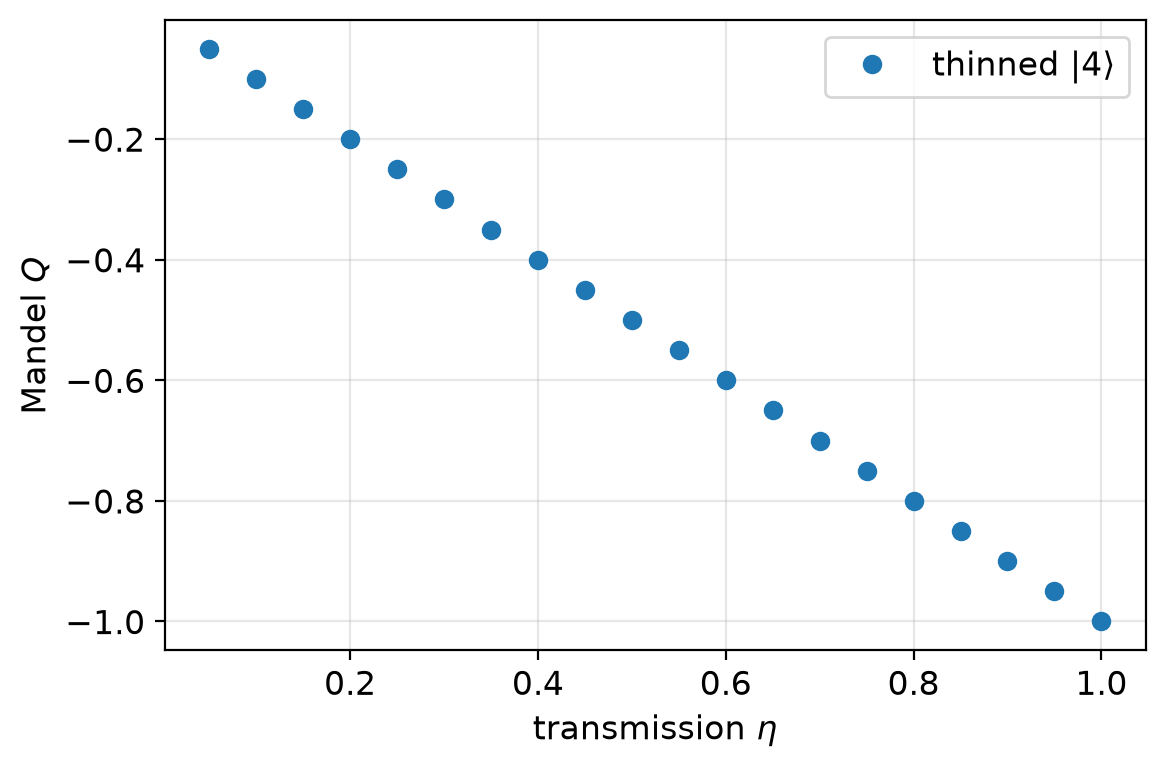

In [10]:
# YOUR CODE HERE - Practice 4 (if time)
# Given - binomial thinning and Q from a distribution:
from scipy.stats import binom

def thin(P, eta):
    """P(n) after transmission eta (binomial thinning)."""
    n_max = len(P)
    out = np.zeros(n_max)
    for n_, pn in enumerate(P):
        if pn > 0:
            out[:n_+1] += pn * binom.pmf(np.arange(n_+1), n_, eta)
    return out

def Q_from_P(P):
    n = np.arange(len(P))
    mean = (n * P).sum()
    var = (n**2 * P).sum() - mean**2
    return (var - mean) / mean

P_fock4 = np.zeros(30); P_fock4[4] = 1.0        # Fock |4>
etas = np.linspace(0.05, 1.0, 20)

# Your physics inputs:
Q_guess_at_50pct = None      # <-- 1. PREDICT Q(|4>) after 50% loss
theory = None                # <-- 2. after the plot: your conjectured law in etas

Q_eta = [Q_from_P(thin(P_fock4, e)) for e in etas]
plt.plot(etas, Q_eta, "o", label="thinned $|4\\rangle$")
if theory is not None:
    plt.plot(etas, theory, "-", label="your law")
if Q_guess_at_50pct is not None:
    plt.plot(0.5, Q_guess_at_50pct, "*", ms=14, label="your prediction")
plt.xlabel(r"transmission $\eta$"); plt.ylabel("Mandel $Q$")
plt.legend(); plt.tight_layout(); plt.show()

## Wrap-up

Tomorrow we discuss the identifications together — bring your verdict table. The notebook and its sample solutions stay online; the remaining exercises are optional take-home material, **nothing needs to be handed in.**

---
---

# Sample solutions

**No peeking during the session.**

### The pitfall ledger — take it to your own data

| exercise | the trap | the defense |
|---|---|---|
| E1 | bin width eats features, or drowns them | resolve the fastest feature ÷5–10; floor at the jitter |
| E2 | a number without σ is an opinion | quote $g^{(2)}(0)\pm\sigma$ + timescale, plot alongside |
| E3 | background dilutes certificates by $(1-p)^2$ | measure $p$ independently; quote raw *and* corrected |
| E4 | least squares invents error bars if you don't | $\sigma = \sqrt{N_c}/A$, `max(N,1)`, `absolute_sigma` |
| E5 | drift fakes bunching under rate normalization | demand $g^{(2)}(\infty) = 1$ — the stationarity check |
| E6 | the normalization silently picks your question | state it explicitly; report the duty cycle |

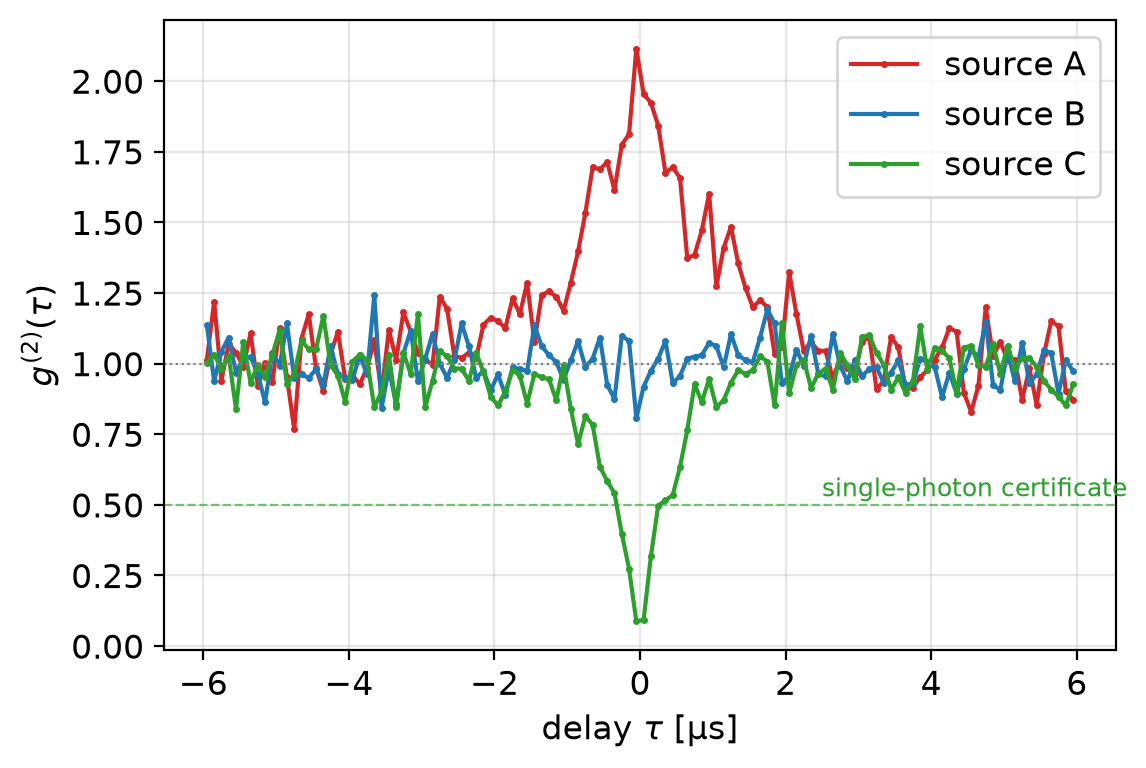

source A: g2(0) = 1.90
source B: g2(0) = 0.98
source C: g2(0) = 0.28


In [11]:
# Solution - Exercise 1
fig, ax = plt.subplots()
g2_zero_values = {}
for letter, color in zip("ABC", ["tab:red", "tab:blue", "tab:green"]):
    d = sources[letter]
    tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
    ax.plot(tau / 1000, g2, ".-", ms=3, color=color, label=f"source {letter}")
    g2_zero_values[letter] = g2[np.abs(tau) < 300].mean()
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.axhline(0.5, color="tab:green", ls="--", lw=0.8, alpha=0.6)
ax.annotate("single-photon certificate", (2.5, 0.53), fontsize=9,
            color="tab:green")
ax.set_xlabel(r"delay $\tau$ [µs]"); ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.legend(); plt.tight_layout(); plt.show()

for letter, v in g2_zero_values.items():
    print(f"source {letter}: g2(0) = {v:.2f}")

**Solution — Exercise 2.** With the seed shipped in the repo: **A = thermal** ($g^{(2)}(0)\approx 1.9$, bunching decays with a $\sim 2$ µs time constant, visible out to $\sim 4$–$5$ µs), **B = coherent** ($g^{(2)}\approx 1$, flat — no structure at any $\tau$), **C = single emitter** ($g^{(2)}(0)\approx 0.3 < 0.5$: certified single-photon source; antibunching recovers with a $\sim 0.5$ µs time constant — the dip is gone by $\sim 1.5$ µs).

Why is C at 0.3 and not 0? Two honest experimental reasons, both built into the simulation: (i) **finite bin width** — 100 ns bins average over the first stretch of the recovery $g^{(2)}(\tau) = 1-e^{-|\tau|/\tau_r}$ with $\tau_r \approx 0.5$ µs (why 0.5 µs and not 1 or 2 µs? — that is Exercise 4) (re-run with `bin_ns=20`: the center bin drops substantially); (ii) **dark counts** (200 cps/detector here) add a small uncorrelated floor. The *source* is fine — the *measurement* has resolution and background. This distinction is half of experimental quantum optics.

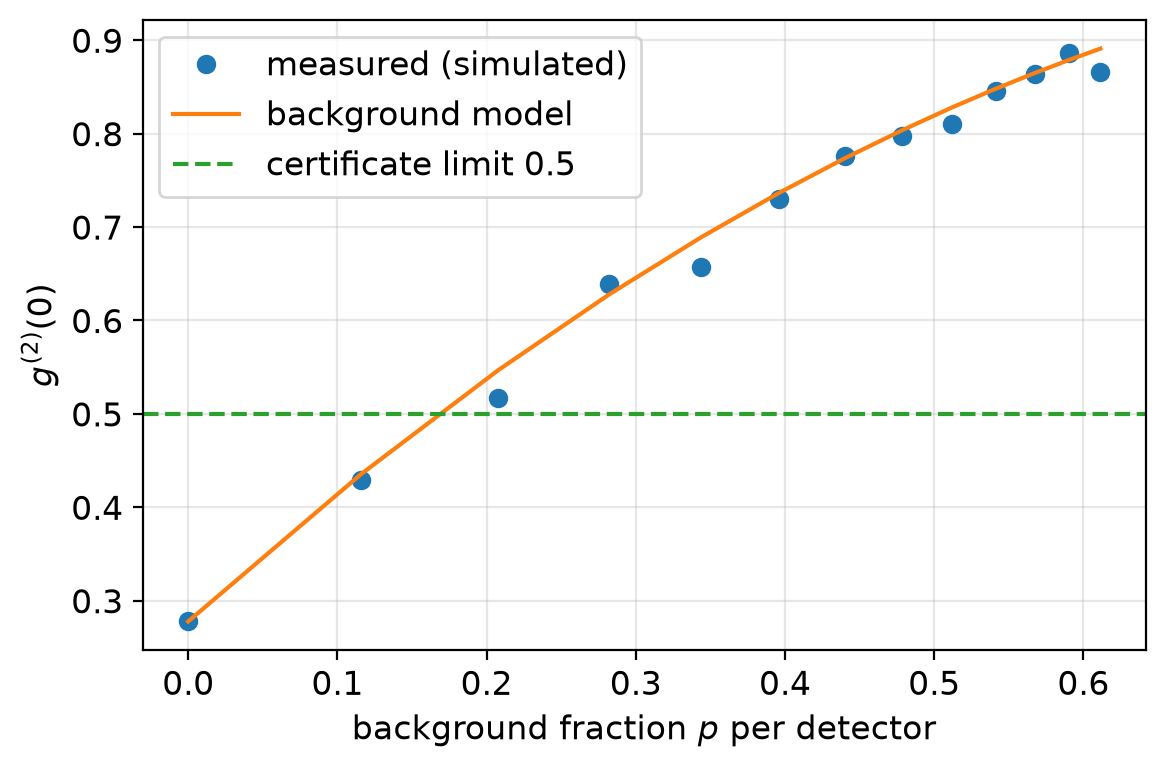

analytic crossing: p* = 0.168 (background rate ≈ 2.6 kcps per detector)


In [12]:
# Solution - Exercise 3
rng = np.random.default_rng(1)

def add_background(t: np.ndarray, duration_ns: float, rate_cps: float,
                   rng: np.random.Generator) -> np.ndarray:
    """Merge uncorrelated Poissonian background clicks into a tag stream.

    Parameters
    ----------
    t : sorted int64 arrival times [ns]
    duration_ns : measurement duration [ns]
    rate_cps : background rate to add [counts/s]
    """
    n_bg = rng.poisson(rate_cps * duration_ns * 1e-9)
    t_bg = rng.integers(0, int(duration_ns), n_bg)
    return np.sort(np.concatenate([t, t_bg]))

d = sources["C"]                       # the antibunched source
signal_rate = d["t1"].size / (d["duration_ns"] * 1e-9)   # cps per detector

bg_rates = np.linspace(0, 20e3, 13)
fractions, g2_measured = [], []
for r_bg in bg_rates:
    t1b = add_background(d["t1"], d["duration_ns"], r_bg, rng)
    t2b = add_background(d["t2"], d["duration_ns"], r_bg, rng)
    tau, g2 = g2_from_timetags(t1b, t2b, d["duration_ns"])
    p = r_bg / (r_bg + signal_rate)
    fractions.append(p)
    g2_measured.append(g2[np.abs(tau) < 300].mean())

fractions = np.array(fractions)
g2_true = g2_measured[0]
theory = g2_true * (1 - fractions)**2 + 2 * fractions * (1 - fractions) \
    + fractions**2

plt.plot(fractions, g2_measured, "o", label="measured (simulated)")
plt.plot(fractions, theory, "-", label="background model")
plt.axhline(0.5, color="tab:green", ls="--", label="certificate limit 0.5")
plt.xlabel("background fraction $p$ per detector")
plt.ylabel(r"$g^{(2)}(0)$")
plt.legend(); plt.tight_layout(); plt.show()

# Compact form and analytic crossing: the formula collapses to
#   g2_meas = 1 - (1 - g2_true) * (1 - p)^2
# so the certificate dies at  p* = 1 - sqrt(0.5 / (1 - g2_true)).
p_star = 1 - np.sqrt(0.5 / (1 - g2_true))
print(f"analytic crossing: p* = {p_star:.3f} "
      f"(background rate ≈ {p_star / (1 - p_star) * signal_rate / 1e3:.1f} kcps "
      "per detector)")


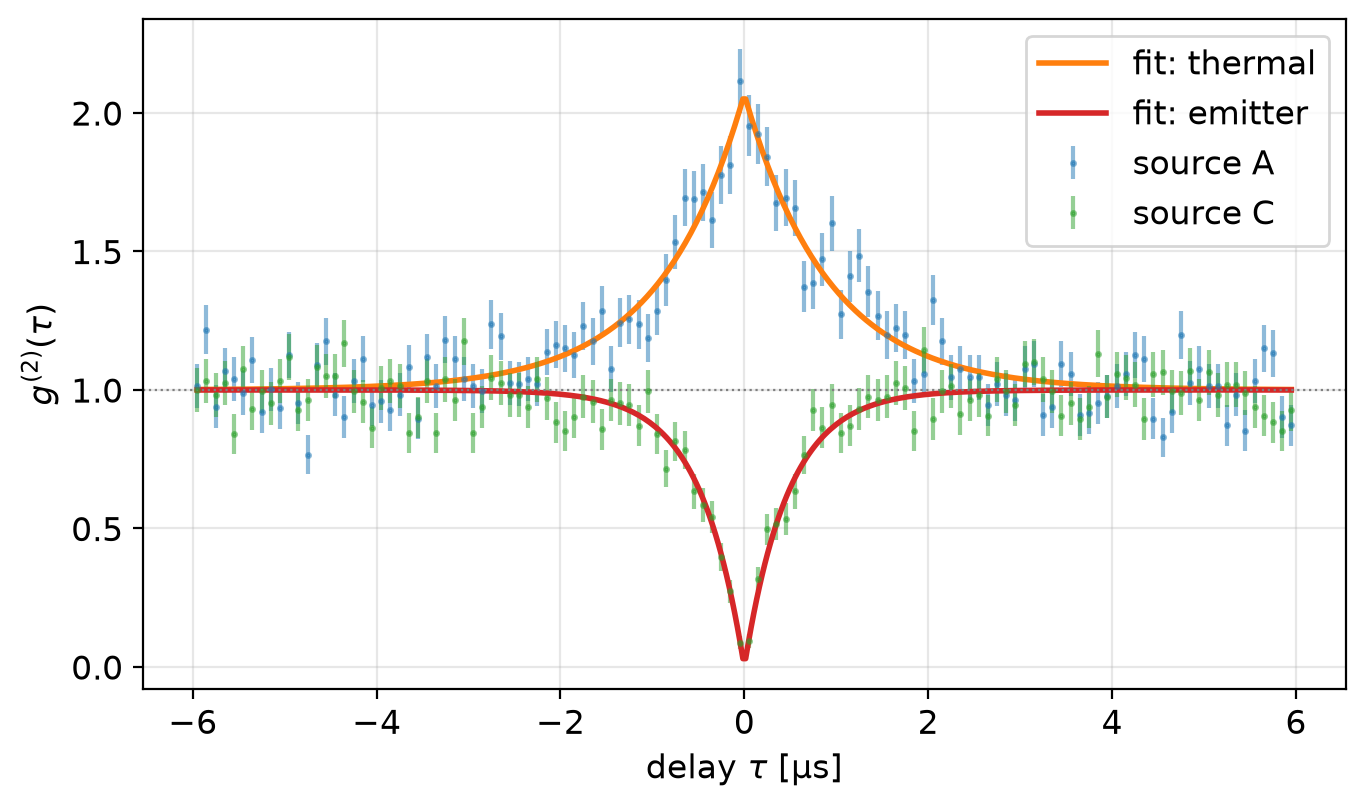

thermal:  tau_c = 1.84 ± 0.10 µs (ground truth: 2 µs)
emitter:  tau_r = 0.48 ± 0.02 µs


In [13]:
# Solution - Exercise 4
from scipy.optimize import curve_fit

def fit_g2(letter: str, model, p0, label: str):
    """Fit a g2(tau) model to one source's coincidence histogram.

    Poisson error bars: a bin with N_c raw coincidences has sigma sqrt(N_c);
    after dividing by the accidental level A the error is sqrt(N_c)/A.
    """
    d = sources[letter]
    tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
    accidentals = (d["t1"].size * d["t2"].size / d["duration_ns"]) * 100  # per 100 ns bin
    sigma = np.sqrt(np.maximum(g2 * accidentals, 1)) / accidentals
    popt, pcov = curve_fit(model, tau, g2, p0=p0, sigma=sigma,
                           absolute_sigma=True)
    perr = np.sqrt(np.diag(pcov))
    plt.errorbar(tau / 1000, g2, yerr=sigma, fmt=".", ms=3, alpha=0.5,
                 label=f"source {letter}")
    tt = np.linspace(tau.min(), tau.max(), 400)
    plt.plot(tt / 1000, model(tt, *popt), "-", lw=2, label=f"fit: {label}")
    return popt, perr

def model_thermal(tau, a, tau_c):
    """Bunching of chaotic light: g2 = 1 + a*exp(-2|tau|/tau_c)."""
    return 1 + a * np.exp(-2 * np.abs(tau) / tau_c)

def model_emitter(tau, b, tau_r):
    """Antibunching recovery: g2 = 1 - b*exp(-|tau|/tau_r)."""
    return 1 - b * np.exp(-np.abs(tau) / tau_r)

plt.figure(figsize=(7, 4.2))
(a, tau_c), (da, dtau_c) = fit_g2("A", model_thermal, [1, 2000], "thermal")
(b, tau_r), (db, dtau_r) = fit_g2("C", model_emitter, [1, 500], "emitter")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]"); plt.ylabel(r"$g^{(2)}(\tau)$")
plt.legend(); plt.tight_layout(); plt.show()

print(f"thermal:  tau_c = {tau_c/1000:.2f} ± {dtau_c/1000:.2f} µs "
      "(ground truth: 2 µs)")
print(f"emitter:  tau_r = {tau_r/1000:.2f} ± {dtau_r/1000:.2f} µs")
# Why is tau_r NOT 2 µs? The photon-to-photon gap is the SUM of two
# exponentials (1 µs excitation + 1 µs emission). For equal rates this
# renewal process has *exactly* g2(tau) = 1 - exp(-2 tau / tau_0) with
# tau_0 = 1 µs, i.e. a recovery constant tau_0/2 = 0.5 µs: the recovery
# rate is the SUM of the two rates, R + Γ - not 1/(cycle duration). Fit shapes are
# physics - always ask which combination of rates your time constant is.

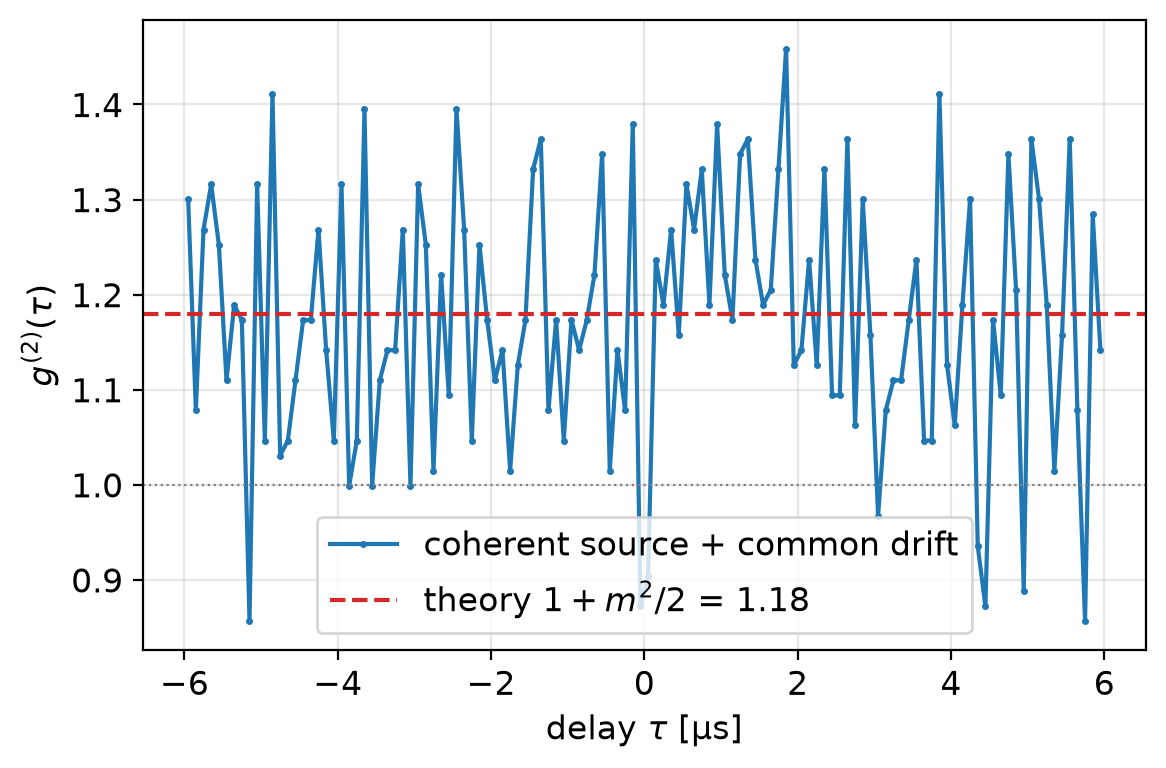

window-averaged g2 = 1.173   theory = 1.180

The whole window floats at 1 + m^2/2: with the r1*r2*T normalization,
slow common drift is DETECTED as a baseline above 1 - the built-in
lie detector. Normalizing by the wings instead would silently absorb
the artifact and the run would look clean. Telling it from real
bunching: extend the window toward T_mod (this excess decays on the
drift period, thermal bunching on tau_c) - or simply log I(t).
Lecture 3's ground-glass pseudo-thermal source is exactly this
effect used on purpose, with controlled m and period.


In [14]:
# Solution - Exercise 5
def modulate(t, m, period_ns, rng):
    """Keep each tag with probability ∝ 1 + m*sin(2π t/period): slow drift."""
    prob = (1 + m * np.sin(2 * np.pi * t / period_ns)) / (1 + m)
    return t[rng.uniform(size=t.size) < prob]

m, period_ns = 0.6, 100_000
rng5 = np.random.default_rng(5)
d = sources["B"]                          # the coherent source
t1m = modulate(d["t1"], m, period_ns, rng5)
t2m = modulate(d["t2"], m, period_ns, rng5)
tau, g2 = g2_from_timetags(t1m, t2m, d["duration_ns"])

plateau_theory = 1 + m**2 / 2
plt.plot(tau / 1000, g2, ".-", ms=3, label="coherent source + common drift")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.axhline(plateau_theory, color="tab:red", ls="--",
            label=rf"theory $1+m^2/2$ = {plateau_theory:.2f}")
plt.xlabel(r"delay $\tau$ [µs]")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.legend(); plt.tight_layout(); plt.show()

print(f"window-averaged g2 = {g2.mean():.3f}   theory = {plateau_theory:.3f}")
print()
print("The whole window floats at 1 + m^2/2: with the r1*r2*T normalization,")
print("slow common drift is DETECTED as a baseline above 1 - the built-in")
print("lie detector. Normalizing by the wings instead would silently absorb")
print("the artifact and the run would look clean. Telling it from real")
print("bunching: extend the window toward T_mod (this excess decays on the")
print("drift period, thermal bunching on tau_c) - or simply log I(t).")
print("Lecture 3's ground-glass pseudo-thermal source is exactly this")
print("effect used on purpose, with controlled m and period.")


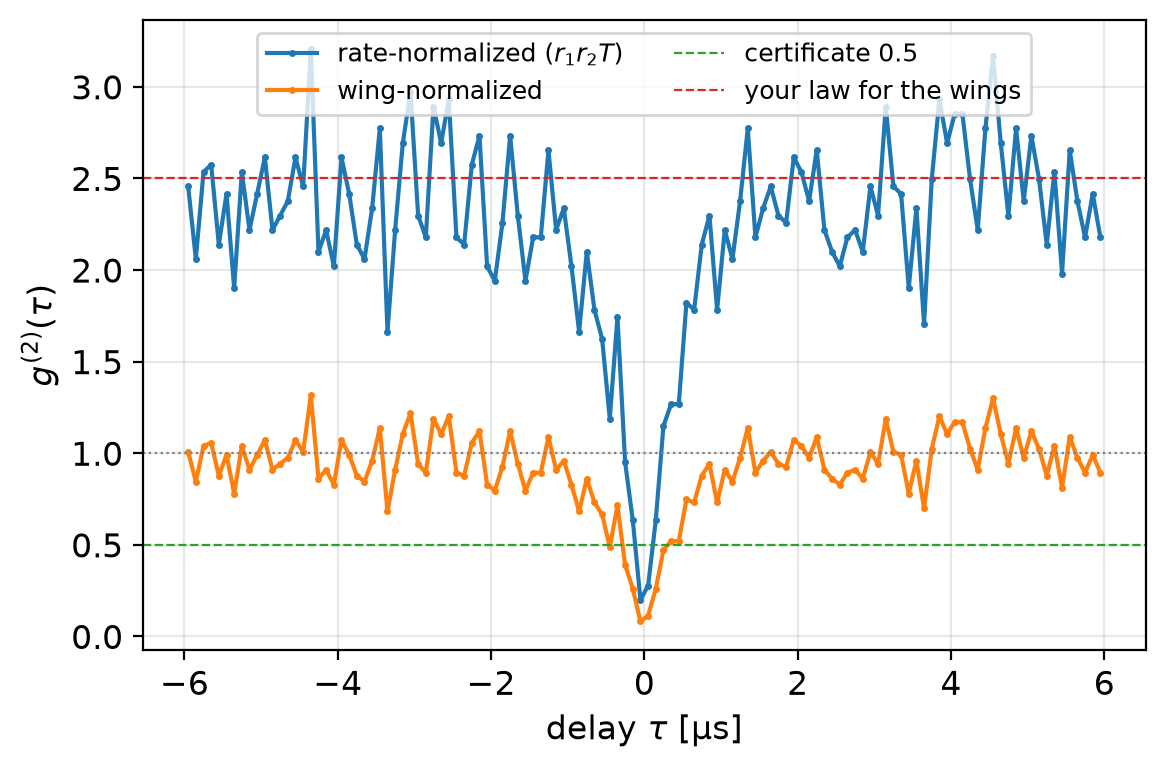

rate-normalized: wings = 2.44, dip = 0.64 -> certificate FAILS
wing-normalized: wings = 1.00, dip = 0.26 -> certificate passes

theory wings = 1/beta = 2.50; measured slightly below -
finite dwell: g2_blink(tau) = 1 + (1-beta)/beta * exp(-|tau|/tau_s)
with tau_s = 60 us sags ~5% across the 6-us window.
Two questions, two answers: as a steady single-photon stream the
source FAILS (it blinks); as an emitter of antibunched photons it
passes cleanly. NV/QD papers therefore quote the wing-normalized
g2(0) - and must say so, or the number is not reproducible.


In [15]:
# Solution - Exercise 6
# Given - a random-telegraph blink gate, applied IN COMMON to both detectors:
def telegraph_edges(dwell_on_ns, dwell_off_ns, duration_ns, rng):
    """Switching times of an ON/OFF telegraph (starts ON)."""
    edges, t, on = [0.0], 0.0, True
    while t < duration_ns:
        t += rng.exponential(dwell_on_ns if on else dwell_off_ns)
        edges.append(t)
        on = not on
    return np.array(edges)

def apply_gate(t, edges):
    """Keep only tags that fall into ON intervals of the telegraph."""
    return t[(np.searchsorted(edges, t, side="right") - 1) % 2 == 0]

dwell_on_ns, dwell_off_ns = 100_000, 150_000    # 100 µs ON / 150 µs OFF
beta = dwell_on_ns / (dwell_on_ns + dwell_off_ns)   # duty cycle = 0.4
rng6 = np.random.default_rng(6)

# Your physics inputs:
emitter = "C"          # the antibunched source
wings_theory = 1 / beta        # slow multiplicative gate: <s^2>/<s>^2

d = sources[emitter]
edges = telegraph_edges(dwell_on_ns, dwell_off_ns, d["duration_ns"], rng6)
t1b = apply_gate(d["t1"], edges)
t2b = apply_gate(d["t2"], edges)
tau, g2 = g2_from_timetags(t1b, t2b, d["duration_ns"])

wings = g2[np.abs(tau) > 4000].mean()      # measured wing level
g2_wing = g2 / wings                       # the wing-normalized curve

fig, ax = plt.subplots()
ax.plot(tau / 1000, g2, ".-", ms=3, label="rate-normalized ($r_1 r_2 T$)")
ax.plot(tau / 1000, g2_wing, ".-", ms=3, label="wing-normalized")
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.axhline(0.5, color="tab:green", ls="--", lw=0.8, label="certificate 0.5")
if wings_theory is not None:
    ax.axhline(wings_theory, color="tab:red", ls="--", lw=0.8,
               label="your law for the wings")
ax.set_xlabel(r"delay $\tau$ [µs]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.legend(fontsize=9, ncol=2, loc="upper center")
plt.tight_layout(); plt.show()

dip = g2[np.abs(tau) < 300].mean()
dip_w = g2_wing[np.abs(tau) < 300].mean()
print(f"rate-normalized: wings = {wings:.2f}, dip = {dip:.2f} -> "
      f"certificate {'passes' if dip < 0.5 else 'FAILS'}")
print(f"wing-normalized: wings = 1.00, dip = {dip_w:.2f} -> "
      f"certificate {'passes' if dip_w < 0.5 else 'FAILS'}")

print()
print(f"theory wings = 1/beta = {1/beta:.2f}; measured slightly below -")
print("finite dwell: g2_blink(tau) = 1 + (1-beta)/beta * exp(-|tau|/tau_s)")
print("with tau_s = 60 us sags ~5% across the 6-us window.")
print("Two questions, two answers: as a steady single-photon stream the")
print("source FAILS (it blinks); as an emitter of antibunched photons it")
print("passes cleanly. NV/QD papers therefore quote the wing-normalized")
print("g2(0) - and must say so, or the number is not reproducible.")


---

## Take-home appendix · more of Monday's toolbox

Three exercises with sample solutions below — same style, no deadline: **P1** (rebuild the fingerprint figure in QuTiP), **P2** (write `mandel_Q` yourself — P3 and P4 up in the session section lean on it), **P5** (Wigner functions and which non-classicality witness fires for which state) — plus the **stretch**: reconstruct $P(n)$ itself from click statistics, Lecture 3's detector POVM in action.

In [16]:
# Setup for the practice exercises: states live in a truncated Fock
# space of dimension N (keep nbar + 5*sqrt(nbar) well below N).
N = 100
rng = np.random.default_rng(42)   # reproducible "experiments"

def photon_number_distribution(state) -> np.ndarray:
    """P(n) = diagonal of the density matrix in the Fock basis."""
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

### P1 · The fingerprint figure

Recreate the central figure of Lecture 1: $P(n)$ for a **Fock**, a **coherent**, and a **thermal** state, *all with* $\bar n = 5$, in one plot (bars or steps, your choice — label everything).

*New physics to notice while you plot:* at $\bar n = 5$, what is the single most likely photon number for the thermal state?

In [17]:
# YOUR CODE HERE - Practice 1
# psi_fock = ...
# psi_coh = ...
# rho_th = ...

In [18]:
# ✅ self-check for Practice 1 (run after your solution)
try:
    for name, st in [("Fock", psi_fock), ("coherent", psi_coh),
                     ("thermal", rho_th)]:
        P = photon_number_distribution(st)
        mean = np.sum(np.arange(len(P)) * P)
        assert abs(mean - 5) < 0.05, f"{name}: <n> = {mean:.2f}, expected 5"
    assert photon_number_distribution(rho_th)[0] > \
           photon_number_distribution(rho_th)[1], \
           "thermal P(0) should exceed P(1) - always!"
    print("Practice 1 looks correct: all three states have <n> = 5,")
    print("and yes - for thermal light n=0 is STILL the most likely outcome.")
except NameError:
    print("(not solved yet - define psi_fock, psi_coh, rho_th above)")

(not solved yet - define psi_fock, psi_coh, rho_th above)


### P2 · A `mandel_Q` function

Write the function below and test it. Reminder from the lecture:

$$Q = \frac{(\Delta n)^2 - \bar n}{\bar n},\qquad (\Delta n)^2 = \langle \hat n^2\rangle - \langle \hat n\rangle^2 .$$

Useful QuTiP bits: `qutip.num(N)` is $\hat n$; `qutip.expect(op, state)` works for kets *and* density matrices; operators square with `**2`.

Expected values: coherent $\to 0$, thermal $\to \bar n$, Fock $\to -1$.

In [19]:
def mandel_Q(state) -> float:
    """Mandel Q parameter: (variance - mean)/mean of the photon number.

    Q = 0 Poissonian | Q < 0 sub-Poissonian (non-classical) | Q > 0 super-P.
    """
    # YOUR CODE HERE - Practice 2
    raise NotImplementedError

In [20]:
# ✅ self-check for Practice 2
try:
    q_coh = mandel_Q(qutip.coherent(N, 2.0))
    q_th = mandel_Q(qutip.thermal_dm(N, 4.0))
    q_fock = mandel_Q(qutip.fock(N, 4))
    assert abs(q_coh) < 1e-6, f"coherent: Q = {q_coh}, expected 0"
    assert abs(q_th - 4.0) < 1e-3, f"thermal nbar=4: Q = {q_th}, expected 4"
    assert abs(q_fock + 1.0) < 1e-9, f"Fock: Q = {q_fock}, expected -1"
    print(f"Practice 2 correct:  Q_coh = {q_coh:+.4f}, "
          f"Q_th = {q_th:+.4f}, Q_fock = {q_fock:+.4f}")
except NotImplementedError:
    print("(not solved yet - implement mandel_Q above)")

(not solved yet - implement mandel_Q above)


### P5 · See the states: Wigner functions

The lecture's phase-space triptych, but yours. Plot the Wigner function (`qutip.wigner(state, xvec, xvec)` on `xvec = np.linspace(-6, 6, 201)`) for:

1. the vacuum $|0\rangle$ and the Fock state $|1\rangle$,
2. your coherent and thermal states from P1,
3. *(from the lecture's LIGO section)* the squeezed vacuum `qutip.squeeze(N, 0.7) * qutip.fock(N, 0)`.

For each: is it negative anywhere? Print the minimum value. Then compute $\Delta X$ and $\Delta P$ for each state (`qutip.variance(qutip.position(N), state)` etc.) and compare with the vacuum value $1/\sqrt2$: **which states beat vacuum noise in some quadrature — and is the Fock state among them?** (It is not: its rings sit *outside* the vacuum disk in every direction — Lecture 1's misconception box, now in your own numbers.) Which of your states are certified non-classical by Wigner negativity, and which by $Q < 0$ — and is it the *same* set? (It is not! Squeezed vacuum: $W$-positive-Gaussian yet non-classical by quadrature noise; $|1\rangle$: both witnesses fire. Different witnesses see different quantumness.)

In [21]:
# YOUR CODE HERE - Practice 5
xvec = np.linspace(-6, 6, 201)


### Take-home stretch · Measure $P(n)$ itself with click detectors

The lecture's punchline: a multiplexed click detector measures $C(k) = \sum_n P(k|n) P(n)$, a *known* linear distortion of $P(n)$ — so you can invert it. This is precisely how the fiber-loop detector of [Achilles2003] works (8 time bins, 2 APDs — the same $M = 8$ you will simulate), and the approach behind SNSPD-array photon counting today (see [Eisaman2011] for the detector landscape). Do the full pipeline, simulation to reconstruction:

1. **Simulate** a pulsed measurement: 20 000 pulses from a source with $\bar n = 2$ (do a thermal and a Fock $|2\rangle$ source), an $M = 8$ multiplexed detector with $\eta = 0.6$. Per pulse: draw $n$ from $P(n)$, keep each photon with probability $\eta$, throw the survivors into 8 bins at random, count occupied bins → $k$. Histogram the $k$'s.
2. **Build the matrix** $A_{kn} = P(k|n)$ from the lecture formula (loss binomial × bin-occupancy inclusion–exclusion; copy `click_matrix` from lecture notebook 03).
3. **Invert**: solve $C = A P$ for $P \ge 0$ with `scipy.optimize.nnls` (never plain `np.linalg.lstsq` — negative probabilities await). Normalize. Compare reconstructed vs true $P(n)$.
4. **Break it**: repeat at $\eta = 0.3$. Where does the reconstruction start inventing structure? (This ill-conditioning under loss is *the* practical limit of photon-number tomography.)

In [22]:
# YOUR CODE HERE - Stretch exercise
from scipy.optimize import nnls
n_pulses = 20_000
M, eta = 8, 0.6


---

### Practice solutions

**Try first — peek later.**

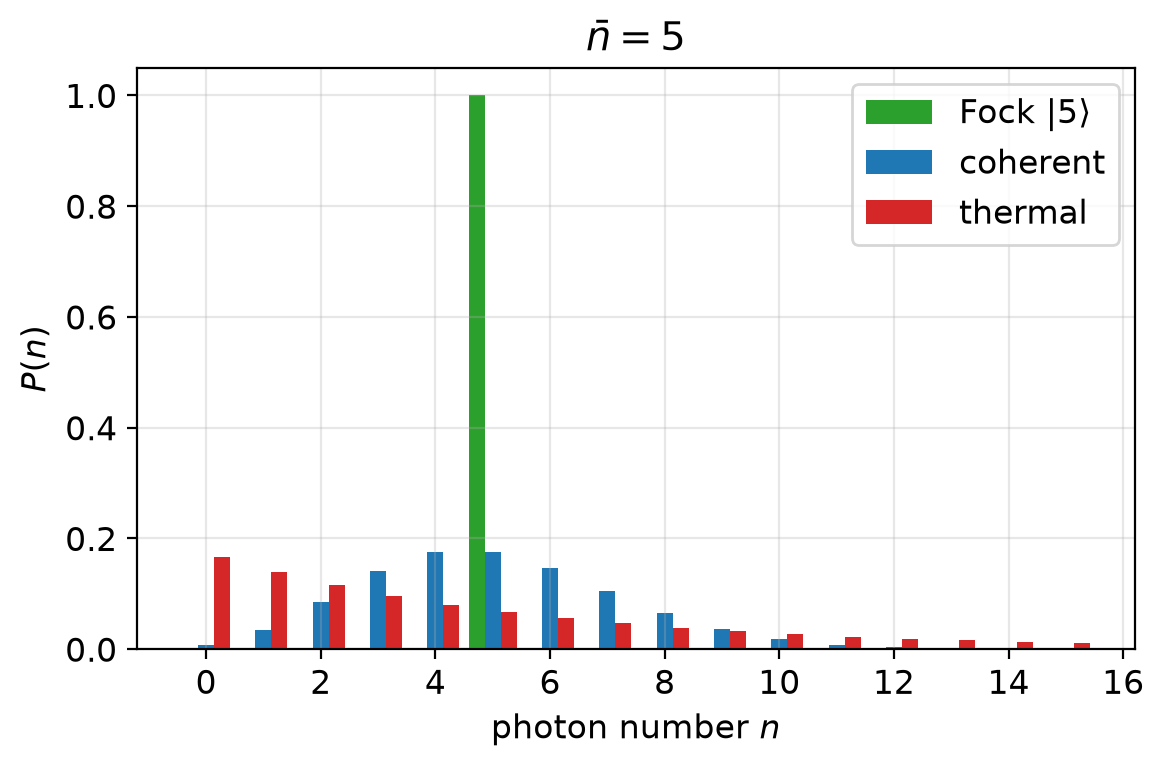

In [23]:
# Solution - Practice 1
nbar = 5
psi_fock = qutip.fock(N, nbar)
psi_coh = qutip.coherent(N, np.sqrt(nbar))
rho_th = qutip.thermal_dm(N, nbar)

n_axis = np.arange(16)
width = 0.28
fig, ax = plt.subplots()
for i, (label, st, c) in enumerate([("Fock $|5\\rangle$", psi_fock, "tab:green"),
                                    ("coherent", psi_coh, "tab:blue"),
                                    ("thermal", rho_th, "tab:red")]):
    ax.bar(n_axis + (i - 1) * width,
           photon_number_distribution(st)[:len(n_axis)], width,
           label=label, color=c)
ax.set_xlabel("photon number $n$"); ax.set_ylabel("$P(n)$")
ax.set_title(r"$\bar{n} = 5$"); ax.legend(); plt.tight_layout(); plt.show()

In [24]:
# Solution - Practice 2
def mandel_Q(state) -> float:
    """Mandel Q parameter: (variance - mean)/mean of the photon number."""
    n_op = qutip.num(state.shape[0])
    mean = qutip.expect(n_op, state)
    var = qutip.expect(n_op**2, state) - mean**2
    return (var - mean) / mean

for label, st in [("coherent", psi_coh), ("thermal", rho_th),
                  ("Fock", psi_fock)]:
    print(f"{label:9s} Q = {mandel_Q(st):+.4f}")

coherent  Q = -0.0000
thermal   Q = +5.0000
Fock      Q = -1.0000


In [25]:
# Solution - Practice 3 (with bootstrap error bars)
def Q_of(samples: np.ndarray) -> float:
    """Sample estimate of the Mandel Q parameter."""
    return (np.var(samples) - np.mean(samples)) / np.mean(samples)

n_shots = 10_000
n_boot = 200
print(f"{'state':<10}{'Q exact':>9}{'Q estimated':>18}")
for label, st in [("coherent", psi_coh), ("thermal", rho_th),
                  ("Fock", psi_fock)]:
    P = photon_number_distribution(st)
    P = P / P.sum()                       # numerical safety renormalization
    samples = rng.choice(np.arange(N), size=n_shots, p=P)
    # bootstrap: resample the *measured data* with replacement
    q_boot = [Q_of(rng.choice(samples, size=samples.size))
              for _ in range(n_boot)]
    print(f"{label:<10}{mandel_Q(st):>+9.3f}"
          f"{Q_of(samples):>+12.3f} ± {np.std(q_boot):.3f}")
# With n_shots = 100 the Fock-state error bar grows to ~0.1-0.2 and
# Q + 2*sigma can cross zero: certifying non-classicality takes statistics,
# not one lucky run.

state       Q exact       Q estimated
coherent     -0.000      +0.006 ± 0.014
thermal      +5.000      +4.812 ± 0.102
Fock         -1.000      -1.000 ± 0.000


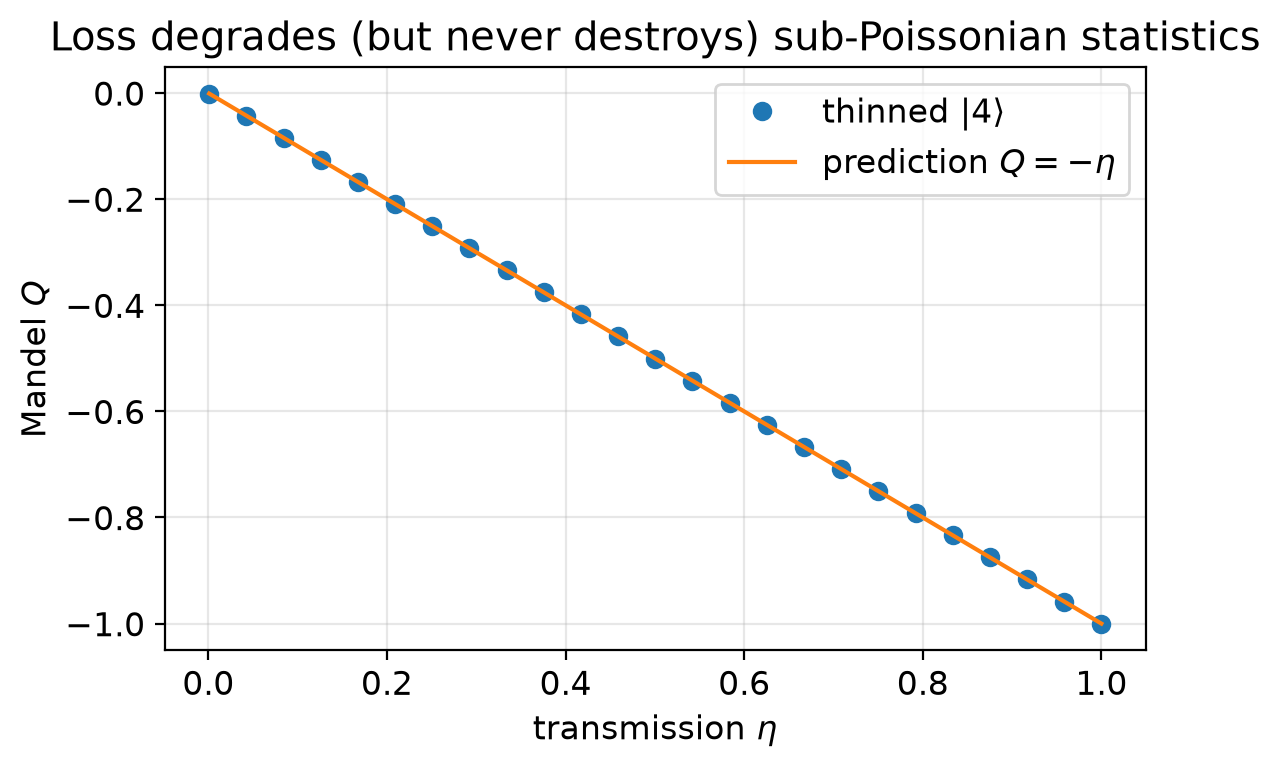

In [26]:
# Solution - Practice 4 (loss)
from scipy.stats import binom

def thin(P: np.ndarray, eta: float) -> np.ndarray:
    """Binomial thinning of a photon number distribution with transmission eta."""
    N_dim = len(P)
    P_out = np.zeros(N_dim)
    for n in range(N_dim):
        if P[n] > 0:
            m = np.arange(n + 1)
            P_out[:n + 1] += P[n] * binom.pmf(m, n, eta)
    return P_out

P4 = np.zeros(N)   # Fock |4>: all probability on n = 4 - no QuTiP needed
P4[4] = 1.0
eta_axis = np.linspace(0.001, 1, 25)
Q_vals = []
for eta in eta_axis:
    Pt = thin(P4, eta)
    n = np.arange(N)
    mean = np.sum(n * Pt)
    var = np.sum(n**2 * Pt) - mean**2
    Q_vals.append((var - mean) / mean)

plt.plot(eta_axis, Q_vals, "o", label="thinned $|4\\rangle$")
plt.plot(eta_axis, -eta_axis, "-", label=r"prediction $Q = -\eta$")
plt.xlabel(r"transmission $\eta$"); plt.ylabel("Mandel $Q$")
plt.title("Loss degrades (but never destroys) sub-Poissonian statistics")
plt.legend(); plt.tight_layout(); plt.show()

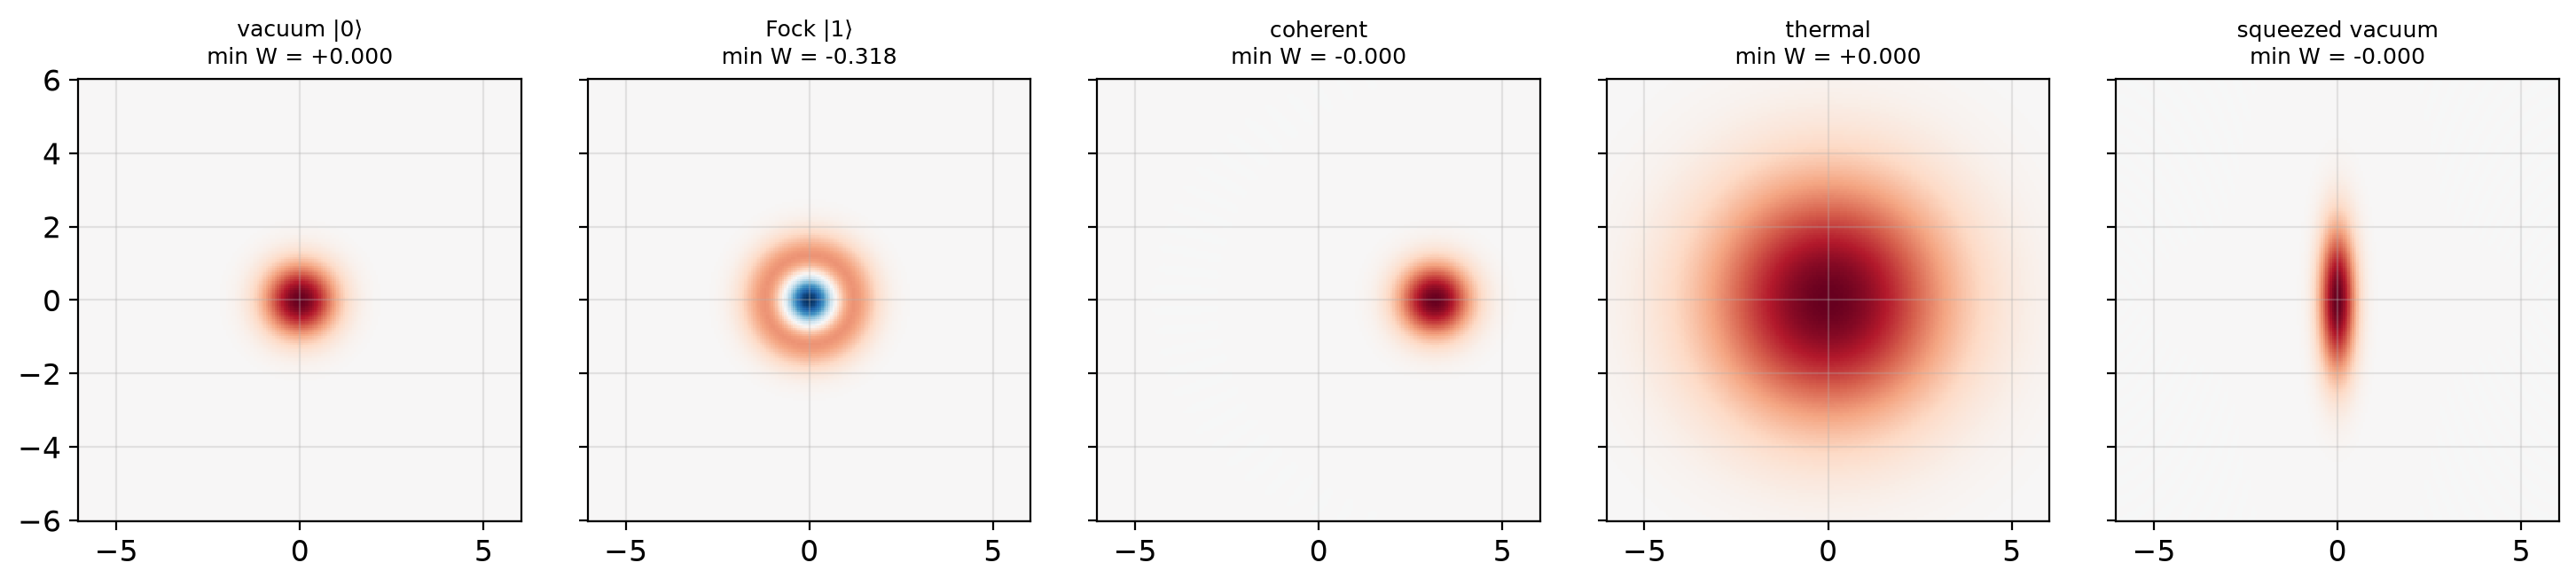

Wigner-negative (hence non-classical): only |1> here.
Q < 0: only |1> as well - but squeezed vacuum is non-classical too
(squeezed quadrature noise), and BOTH its Q and min(W) miss it. 
No single witness catches all quantum states.

state                  dX     dP   (vacuum: 0.707)
vacuum $|0\rangle$  0.707  0.707
Fock $|1\rangle$    1.225  1.225
coherent            0.707  0.707
thermal             2.345  2.345
squeezed vacuum     0.351  1.424  <- squeezed!


In [27]:
# Solution - Practice 5
xvec = np.linspace(-6, 6, 201)
states_4 = [(r"vacuum $|0\rangle$", qutip.fock(N, 0)),
            (r"Fock $|1\rangle$", qutip.fock(N, 1)),
            ("coherent", psi_coh),
            ("thermal", rho_th),
            ("squeezed vacuum", qutip.squeeze(N, 0.7) * qutip.fock(N, 0))]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.1), sharey=True)
for ax, (label, st) in zip(axes, states_4):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{label}\nmin W = {W.min():+.3f}", fontsize=9)
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

print("Wigner-negative (hence non-classical): only |1> here.")
print("Q < 0: only |1> as well - but squeezed vacuum is non-classical too")
print("(squeezed quadrature noise), and BOTH its Q and min(W) miss it. ")
print("No single witness catches all quantum states.")

# ...and the quadrature-noise check: who is actually squeezed?
x_op, p_op = qutip.position(N), qutip.momentum(N)
print(f"\n{'state':<18}{'dX':>7}{'dP':>7}   (vacuum: 0.707)")
for label, st in states_4:
    dx = np.sqrt(qutip.variance(x_op, st))
    dp = np.sqrt(qutip.variance(p_op, st))
    tag = "  <- squeezed!" if min(dx, dp) < 1 / np.sqrt(2) - 1e-6 else ""
    print(f"{label:<18}{dx:>7.3f}{dp:>7.3f}{tag}")
# Only the squeezed vacuum beats the vacuum level. The Fock state |1> is
# Wigner-negative yet NOT squeezed - two orthogonal kinds of quantumness.

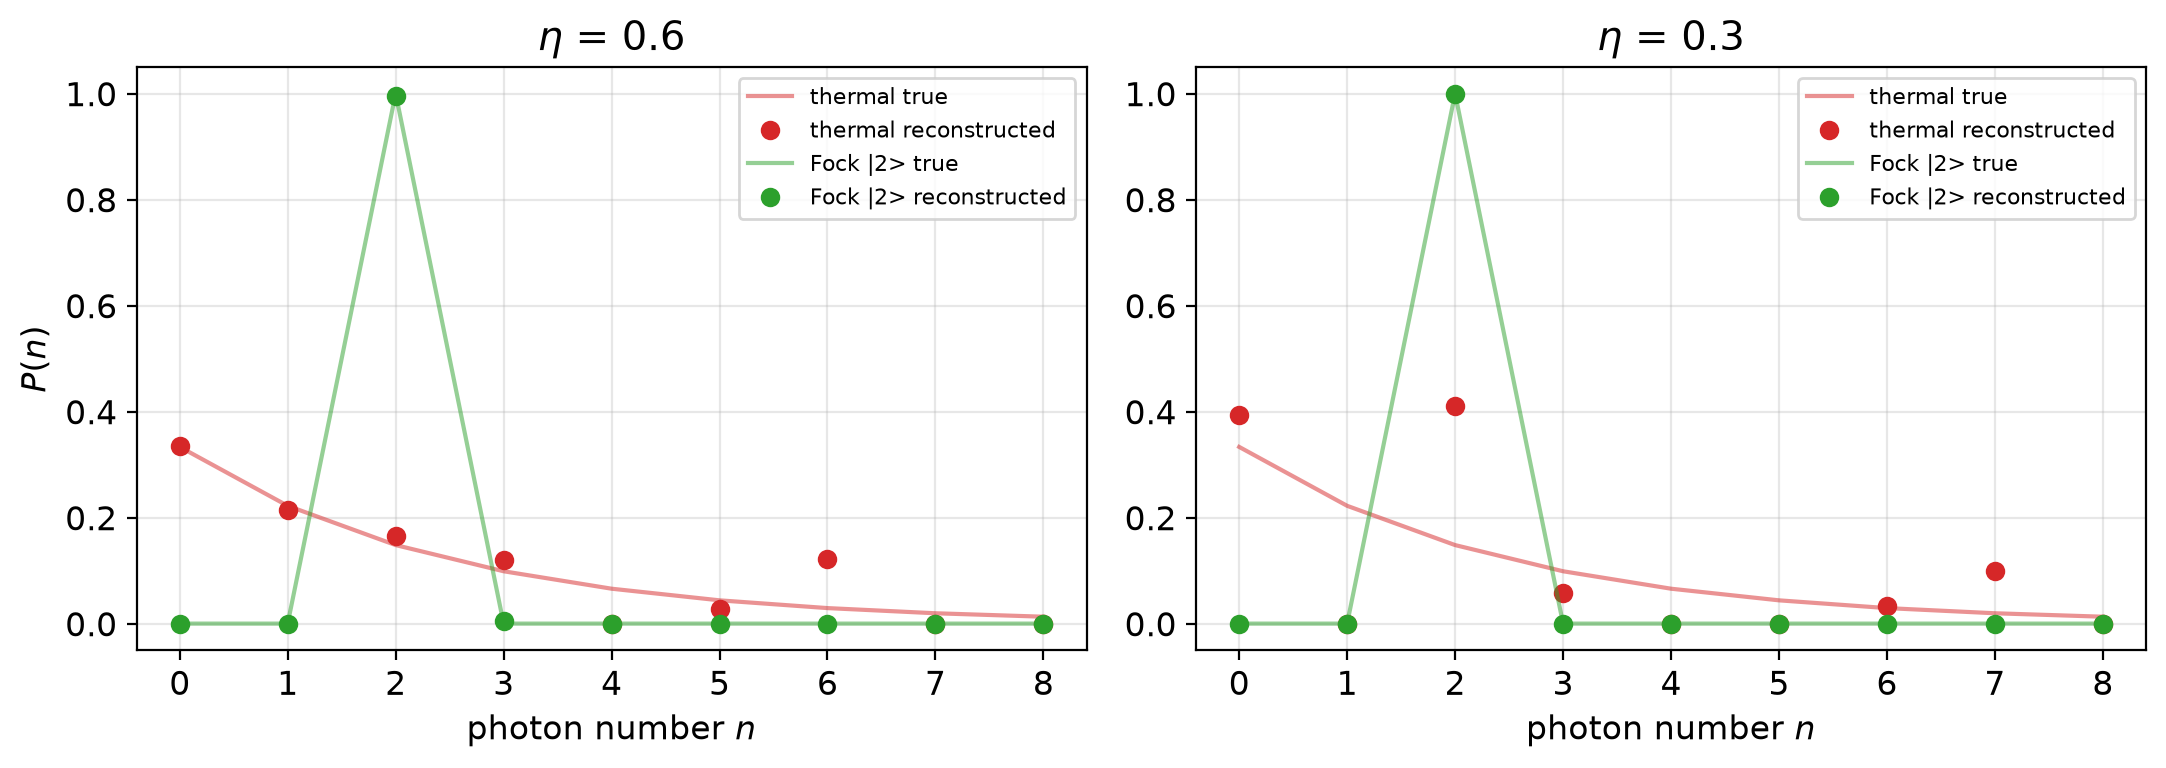

In [28]:
# Solution - Take-home stretch (P(n) reconstruction from clicks)
from scipy.optimize import nnls
from scipy.special import comb as scomb, factorial

rng = np.random.default_rng(4)
n_pulses, M, n_max = 20_000, 8, 25
nbar = 2.0
n_ax = np.arange(n_max)
sources_pn = {
    "thermal": nbar**n_ax / (1 + nbar)**(n_ax + 1),
    "Fock |2>": (n_ax == 2).astype(float),
}

def click_matrix(M: int, eta: float, n_max: int) -> np.ndarray:
    """A[k, n] = P(k clicks | n photons) for an M-bin multiplexed detector."""
    A = np.zeros((M + 1, n_max))
    for n in range(n_max):
        for m in range(n + 1):
            p_loss = scomb(n, m) * eta**m * (1 - eta)**(n - m)
            for k in range(min(m, M) + 1):
                occ = scomb(M, k) * sum(
                    (-1)**i * scomb(k, i) * ((k - i) / M)**m
                    for i in range(k + 1))
                A[k, n] += p_loss * occ
    return A

def simulate_clicks(P: np.ndarray, eta: float) -> np.ndarray:
    """Monte-Carlo click histogram C(k) for n_pulses pulses."""
    n_photons = rng.choice(n_ax, size=n_pulses, p=P / P.sum())
    C = np.zeros(M + 1)
    for n in n_photons:
        m = rng.binomial(n, eta)                      # loss
        k = len(set(rng.integers(0, M, m)))           # occupied bins
        C[k] += 1
    return C / n_pulses

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, eta in zip(axes, [0.6, 0.3]):
    A = click_matrix(M, eta, n_max)
    for label, P_true in sources_pn.items():
        C = simulate_clicks(P_true, eta)
        P_rec, _ = nnls(A, C)                         # non-negative inversion
        P_rec = P_rec / P_rec.sum()
        color = "tab:red" if "thermal" in label else "tab:green"
        ax.plot(n_ax[:9], P_true[:9], "-", color=color, alpha=0.5,
                label=f"{label} true")
        ax.plot(n_ax[:9], P_rec[:9], "o", color=color,
                label=f"{label} reconstructed")
    ax.set_title(f"$\\eta$ = {eta}")
    ax.set_xlabel("photon number $n$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("$P(n)$")
plt.tight_layout(); plt.show()
# eta = 0.6: faithful reconstruction from binary detectors - this is how
# P(n) is measured in practice (time-multiplexed detectors, SNSPD arrays).
# eta = 0.3: the inversion amplifies statistical noise into spurious
# structure - loss makes A ill-conditioned. (Fock |2> still comes out
# clean: its P(n) is a single spike, and such sparse support survives
# the non-negativity constraint of nnls, which clips the oscillating
# noise artifacts to zero - the broad thermal tail has no such shield.) Photon-number tomography is
# an efficiency game, like everything else this week.